# Data Mining Project - Group XX 2025/2026

# Import Libraries

In [1]:
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

from itertools import product
from ydata_profiling import ProfileReport

# for better resolution plots
%config InlineBackend.figure_format = 'retina'

#o svg consegue ampliar infinitamente os gráficos sem perder qualidade mas às vezes é mais lento 
#por isso agora usamos retina

np.random.seed(40311)
sns.set()

# Loading the Data

Import the datasets from csv files using commas as separators of the columns and setting the unique customer identifier as the index of both columns.

In [2]:
flightsDB = pd.read_csv('data/DM_AIAI_FlightsDB.csv', sep = ",", index_col= "Loyalty#")
customerDB = pd.read_csv('data/DM_AIAI_CustomerDB.csv', sep = ",", index_col= "Loyalty#")
metaData = pd.read_csv('data/DM_AIAI_Metadata.csv', sep = ";", header= None)

Remove the 'Unnamed' column referring to a sequential numbering of the rows, as we set the column "Loyalty#" as the index

In [3]:
customerDB = customerDB.iloc[:, 1:]
customerDB

,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
Loyalty#,,,,,,,,,,,,,,,,,,,
480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100012,Ethan,Thompson,Ethan Thompson,Canada,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,NaN,Single,Star,2/27/2019,2/27/2019,NaN,Standard
100013,Layla,Young,Layla Young,Canada,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,NaN,Married,Star,9/20/2017,9/20/2017,NaN,Standard
100014,Amelia,Bennett,Amelia Bennett,Canada,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,NaN,Married,Star,11/28/2020,11/28/2020,NaN,Standard


# Metadata

**FlightsDB Database feature Description**
- **Loyalty#:**	Unique customer identifier linking to CustomerDB
- **Year:**	Year of flight activity record
- **Month:**	Month of flight activity record (1-12)
- **YearMonthDate:**	First day of the month for the activity period
- **NumFlights:**	Total number of flights taken by customer in the month
- **NumFlightsWithCompanions:**	Number of flights where customer traveled with companions
- **DistanceKM:**	Total distance traveled in kilometers for the month
- **PointsAccumulated:**	Loyalty points earned by customer during the month
- **PointsRedeemed:**	Loyalty points spent/redeemed by customer during the month
- **DollarCostPointsRedeemed:**	Dollar value of points redeemed during the month

**CustomerDB Database feature Description**
- **Loyalty#:**  Unique customer identifier for loyalty program members
- **First Name:**   Customer's first name
- **Last Name:**   Customer's last name 
- **Customer Name:** Customer's full name (concatenated)
- **Country:**	Customer's country of residence
- **Province or State:**	Customer's province or state
- **City:**	Customer's city of residence
- **Latitude:**	Geographic latitude coordinate of customer location
- **Longitude:**	Geographic longitude coordinate of customer locatio
- **Postal code:**	Customer's postal/ZIP code
- **Gender:**	Customer's gender
- **Education:**	Customer's highest education level (Bachelor, College, etc.)
- **Location:** Code	Urban/Suburban/Rural classification of customer residence
- **Income:**	Customer's annual income
- **Marital Status:**	Customer's marital status (Married, Single, Divorced)
- **LoyaltyStatus:**	Current tier status in loyalty program (Star > Nova > Aurora)
- **EnrollmentDateOpening:**	Date when customer joined the loyalty program
- **CancellationDate:**	Date when customer left the program
- **Customer Lifetime:** Value	Total calculated monetary value of customer relationship
- **EnrollmentType:**	Method of joining loyalty program

# Data Preparation

## Feature Engineering (FlightsDB)

Firstly, we have decided to add the following features aggregated by Loyalty# so that we have the totals of the existing features. The intent of this is to help us create even more meaningful features after and give the full picture of the existing monthly data.
- `TotalFlights:` Total number of flights taken by the customer over their entire membership period.

- `TotalFlightsWithCompanions:` Total number of flights taken with at least one companion.

- `TotalDistanceKM:` Total distance flown (in kilometers) across all flights taken by the customer.

- `TotalPointsAccumulated:` Total loyalty points earned throughout the customer’s history.

- `TotalPointsRedeemed:` Total loyalty points redeemed by the customer.

- `FlightsVariance:` Variance or standard deviation of number of flights per customer over time. Calculated as groupby(Loyalty#)['NumFlights'].var(). Measures consistency in travel patterns.


In [4]:
# Convert YearMonthDate to datetime
flightsDB['YearMonthDate'] = pd.to_datetime(flightsDB['YearMonthDate'])

# Make Loyalty# a column
flightsDB_reset = flightsDB.reset_index()

# Aggregate by customer (lifetime summary metrics) and rename in one step
flightsDB_agg = (
    flightsDB_reset.groupby('Loyalty#', as_index=False)  # keep Loyalty# as a column
    .agg(
        TotalFlights=('NumFlights', 'sum'),
        TotalFlightsWithCompanions=('NumFlightsWithCompanions', 'sum'),
        TotalDistanceKM=('DistanceKM', 'sum'),
        TotalPointsAccumulated=('PointsAccumulated', 'sum'),
        TotalPointsRedeemed=('PointsRedeemed', 'sum'),
        FlightsVariance=('NumFlights', 'var')
    )
)

# Preview
flightsDB_new = flightsDB_agg.copy()
flightsDB_new.describe().T

,count,mean,std,min,25%,50%,75%,max
Loyalty#,16737.0,549735.880445,258912.132453,100018.0,326603.000000,550434.000000,772019.0000,9.999860e+05
TotalFlights,16737.0,142.070443,82.116992,0.0,70.300000,163.000000,203.6000,5.394000e+02
TotalFlightsWithCompanions,16737.0,35.769086,23.797292,0.0,16.000000,36.800000,52.8000,1.447000e+02
TotalDistanceKM,16737.0,288616.904816,166916.274539,0.0,144081.000000,331589.400000,413994.2000,1.059681e+06
TotalPointsAccumulated,16737.0,28856.006327,16688.825594,0.0,14405.000000,33152.440000,41393.5200,1.059516e+05
TotalPointsRedeemed,16737.0,8552.045767,8751.750064,0.0,0.000000,6519.000000,13607.2000,5.752780e+04
FlightsVariance,16737.0,21.175935,10.911327,0.0,15.188635,23.298571,28.9785,5.039892e+01


We will add the following more complex features to our model in order to better analyse and segment the customers in the future.

- `PointsRedemptionRatio:` The proportion of earned points that a customer has redeemed. Calculated as PointsRedeemed / PointsAccumulated. Shows engagement with the loyalty program and redemption behavior.

- `TotalFlightWithCompanionRatio:` Ratio of flights where the customer traveled with companions. Calculated as NumFlightsWithCompanions / NumFlights. Reveals travel habits for group or family targeting.

- `Recency:` Number of months since the customer last took a trip. Calculated as the time difference between the dataset’s latest recorded date and the customer’s most recent active flight month. A core RFM metric used to evaluate engagement freshness and identify churn risk.

- `DistancePerFlight`: The average distance flown per flight per customer. This allows us to see which customers make short and long trips.

In [5]:
# Latest date in dataset 
latest_date = flightsDB['YearMonthDate'].max()

# PointsRedemptionRatio (Total)
flightsDB_new['PointsRedemptionRatio'] = np.where(
    flightsDB_new['TotalPointsAccumulated'] > 0,
    flightsDB_new['TotalPointsRedeemed'] / flightsDB_new['TotalPointsAccumulated'],
    0
)

# Total Flight With Companion Ratio (lifetime)
flightsDB_new['TotalFlightWithCompanionRatio'] = np.where(
    flightsDB_new['TotalFlights'] > 0,
    flightsDB_new['TotalFlightsWithCompanions'] / flightsDB_new['TotalFlights'],
    0
)

## Recency (months since last active flight)
# Compute last active flight per customer
active_flights = flightsDB[flightsDB['NumFlights'] > 0]
last_active_flight = active_flights.groupby('Loyalty#')['YearMonthDate'].max()

latest_date = flightsDB['YearMonthDate'].max()
flightsDB_new['Recency'] = (
    (latest_date - flightsDB_new['Loyalty#'].map(last_active_flight)).dt.days / 30
).fillna(99).astype(int) # Fill NaN (no active flights) with 99 to highlight inactivity


# Total Distance per Flight
flightsDB_new['DistancePerFlight'] = np.where(
    flightsDB_new['TotalFlights'] > 0,
    flightsDB_new['TotalDistanceKM'] / flightsDB_new['TotalFlights'],
    0
)

flightsDB_new.describe().T

,count,mean,std,min,25%,50%,75%,max
Loyalty#,16737.0,549735.880445,258912.132453,100018.0,326603.000000,550434.000000,772019.000000,9.999860e+05
TotalFlights,16737.0,142.070443,82.116992,0.0,70.300000,163.000000,203.600000,5.394000e+02
TotalFlightsWithCompanions,16737.0,35.769086,23.797292,0.0,16.000000,36.800000,52.800000,1.447000e+02
TotalDistanceKM,16737.0,288616.904816,166916.274539,0.0,144081.000000,331589.400000,413994.200000,1.059681e+06
TotalPointsAccumulated,16737.0,28856.006327,16688.825594,0.0,14405.000000,33152.440000,41393.520000,1.059516e+05
TotalPointsRedeemed,16737.0,8552.045767,8751.750064,0.0,0.000000,6519.000000,13607.200000,5.752780e+04
FlightsVariance,16737.0,21.175935,10.911327,0.0,15.188635,23.298571,28.978500,5.039892e+01
PointsRedemptionRatio,16737.0,0.287281,0.484801,0.0,0.000000,0.215097,0.419533,3.326772e+01
TotalFlightWithCompanionRatio,16737.0,0.235125,0.135974,0.0,0.163934,0.237791,0.308725,1.000000e+00
Recency,16737.0,10.041107,28.124541,0.0,0.000000,0.000000,1.000000,9.900000e+01


### Selecting Created Features

To avoid creating redundant features, we will quickly analyse their correlation and drop the irrelevant ones.

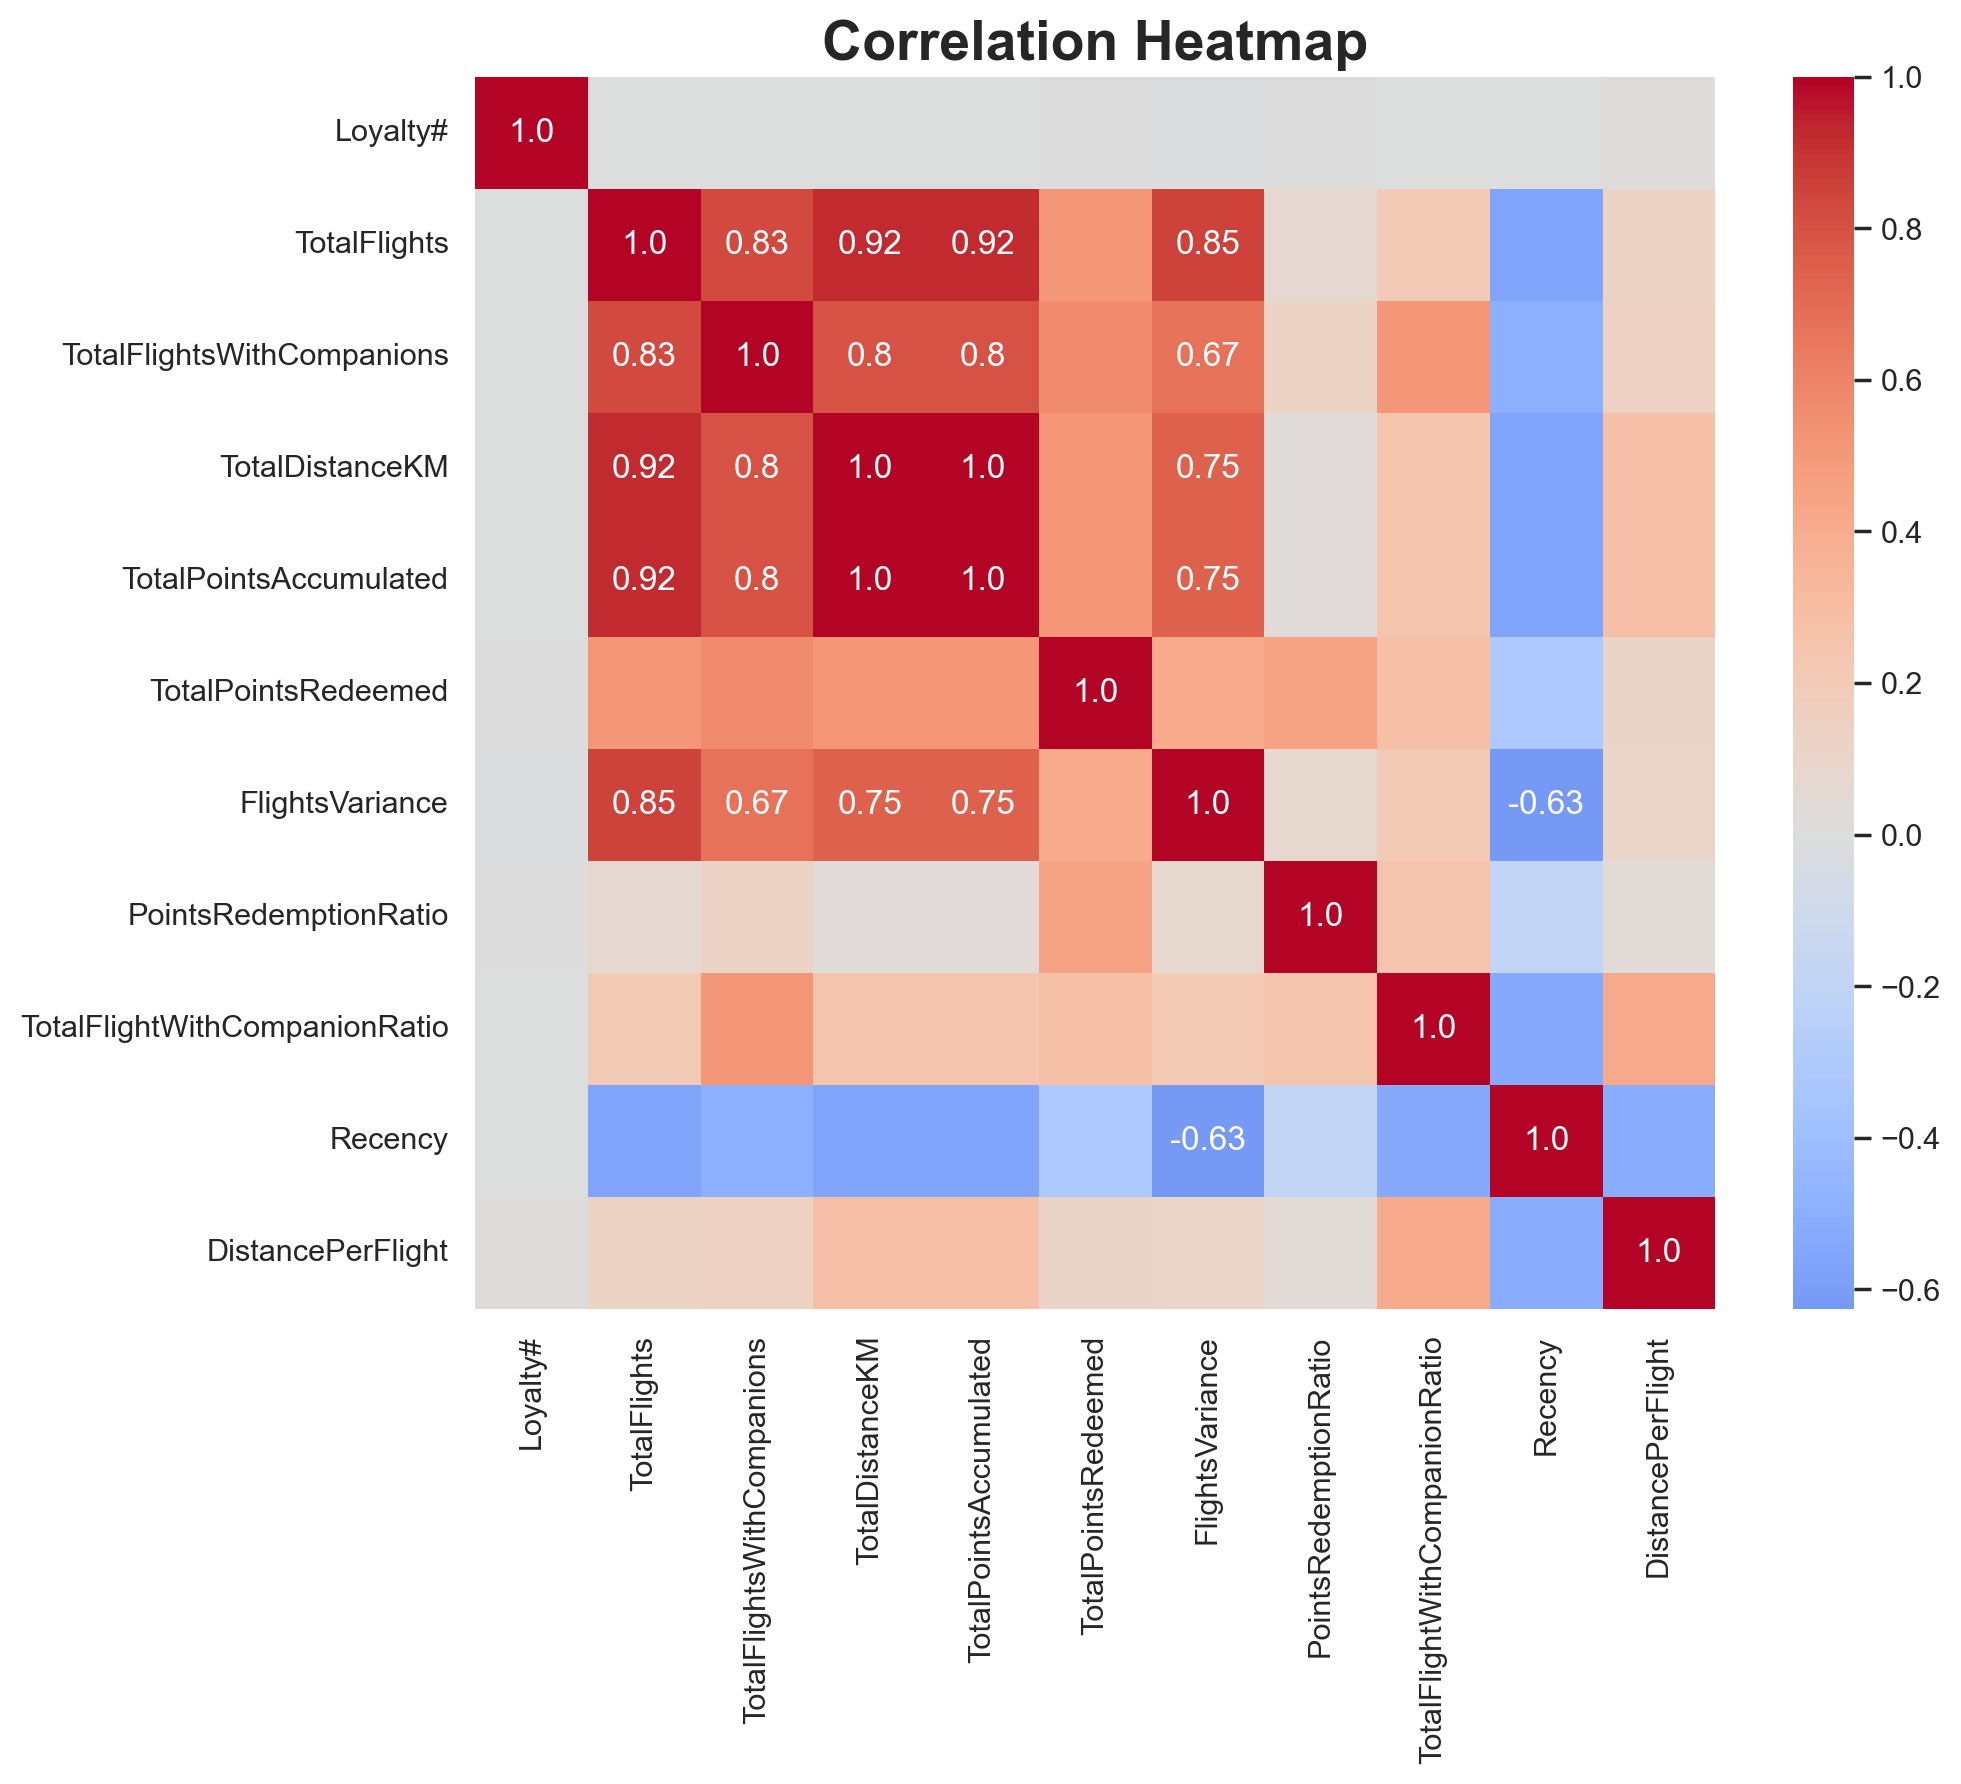

In [6]:
# Compute correlation matrix
corr = flightsDB_new.corr()

# Mask values < 0.5
mask_annot = np.abs(corr.values) >= 0.6
annot = np.where(mask_annot, np.round(corr.values, 2), "")

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(data=corr, annot=annot, fmt="", center=0, cmap="coolwarm")
plt.title("Correlation Heatmap", fontsize=20, fontweight="bold")
plt.show()


With this correlation matrix, we see that there are lots of redundant variables and so, **we decided to keep only the following features:**

- `PointsRedemptionRatio`

- `TotalFlightWithCompanionRatio`

- `Recency`

- `DistancePerFlight`

We decided right away to drop the features related to the total values per customer and use them solely for calculations of other features since they all have high correlations between themselves. Only 'TotalPointsRedeemed' showed a lower correlation, but we dropped it as well since it had moderate correlation with the previous ones and 'PointsRedemptionRatio' whereas this displays much more valuable information.

'FlightsVariance' and 'Recency' also showed high negative correlation and we decided to keep only 'Recency' since its values are easier to interpret.

## Feature Engineering (CustomerDB)

We have decided to add the following features to help us segment the customers later on.
- `IncomeBins:` Groups customers into discrete income categories ranging from low to very high. We divided this into 4 groups, each representing 20% of the dataset, one being very low since we saw there are a lot of customers with 0 income.

- `HouseholdType:` Combined indicator describing both marital status and location type of the customer.

- `MonthsSinceEnrollment:` Number of months since the customer joined the loyalty program.

- `CLVBins:` Categorizes customers into five groups based on their Customer Lifetime Value (CLV), from lowest to highest. Again, each group represents 20% of the dataset.

- `CLVvsCityMean`: Difference between the customer’s CLV and the average CLV for their city.

For the creation of the bins, we decided to do it with equal parts of the dataset because our goal is to analyse and segment the current data we have. It is not important if the bins represent realistic values in the real world since this is all the data we will be working with.


In [ ]:
# Create expanded dataset
customerDB_expanded = customerDB.copy()
customerDB_new = pd.DataFrame()

# Convert enrollment and cancellation dates to datetime
customerDB['EnrollmentDateOpening'] = pd.to_datetime(customerDB_expanded['EnrollmentDateOpening'], errors='coerce')


## INCOME BINS
# Fill NaNs temporarily with -1
income_nonan = customerDB_expanded['Income'].fillna(-1)

# Compute quartiles
try:
    temp_bins = pd.qcut(income_nonan, q=4, duplicates='drop')
    bins_labels = ['Very Low', 'Low', 'Medium', 'High'][:len(temp_bins.cat.categories)]
    customerDB_expanded['IncomeBins'] = pd.qcut(
        income_nonan,
        q=4,
        labels=bins_labels,
        duplicates='drop'
    )
    # Replace the -1 bin with 'Unknown'
    customerDB_expanded['IncomeBins'] = customerDB_expanded['IncomeBins'].cat.add_categories(['Unknown'])
    customerDB_expanded.loc[income_nonan == -1, 'IncomeBins'] = 'Unknown'
except ValueError:
    customerDB_expanded['IncomeBins'] = pd.Series(['Unknown']*len(customerDB_expanded))



# HouseholdType → Marital + Location
customerDB_expanded['HouseholdType'] = (
    customerDB_expanded['Location Code'].fillna('Unknown') + '-' +
    customerDB_expanded['Marital Status'].fillna('Unknown')
)


# MonthsSinceEnrollment
reference_date = pd.Timestamp.today()
customerDB_expanded['MonthsSinceEnrollment'] = (
    (reference_date - customerDB['EnrollmentDateOpening']).dt.days / 30
).fillna(0).clip(lower=0)


# IsActive
customerDB_expanded['IsActive'] = customerDB_expanded['CancellationDate'].isna().astype(int)


# Fill NaNs temporarily with -1
clv_nonan = customerDB_expanded['Customer Lifetime Value'].fillna(-1)

## CLV BINS
# Compute quartiles
try:
    temp_bins = pd.qcut(clv_nonan, q=5, duplicates='drop')
    clv_labels = ["Very Low", "Low", "Medium", "High", "Very High"][:len(temp_bins.cat.categories)]
    customerDB_expanded['CLVBins'] = pd.qcut(
        clv_nonan,
        q=5,
        labels=clv_labels,
        duplicates='drop'
    )
    # Replace the -1 bin with 'Unknown'
    customerDB_expanded['CLVBins'] = customerDB_expanded['CLVBins'].cat.add_categories(['Unknown'])
    customerDB_expanded.loc[clv_nonan == -1, 'CLVBins'] = 'Unknown'
except ValueError:
    customerDB_expanded['CLVBins'] = pd.Series(['Unknown']*len(customerDB_expanded))


# ---  CLV vs City Mean ---
customerDB_expanded['CLVvsCityMean'] = (
    customerDB_expanded['Customer Lifetime Value'] - customerDB_expanded.groupby('City')['Customer Lifetime Value'] \
    .transform('mean')
)

# Copy new columns to customerDB_new
cols_to_copy = [
    'IncomeBins',
    'HouseholdType',
    'MonthsSinceEnrollment',
    'IsActive',
    'CLVBins',
    'CLVvsCityMean'
]

customerDB_new[cols_to_copy] = customerDB_expanded[cols_to_copy]

# Preview result
customerDB_expanded.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
First Name,16921,4941,Deon,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last Name,16921,15404,Salberg,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,16921,16921,Cecilia Householder,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,16921,1,Canada,16921,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province or State,16921,11,Ontario,5468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,16921,29,Toronto,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,16921.0,NaN,NaN,NaN,47.1745,3.307971,42.984924,44.231171,46.087818,49.28273,60.721188
Longitude,16921.0,NaN,NaN,NaN,-91.814768,22.242429,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578
Postal code,16921,75,V6E 3D9,917,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,16921,2,female,8497,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Selecting Created Features

See if it makes sense to keep aall created features.

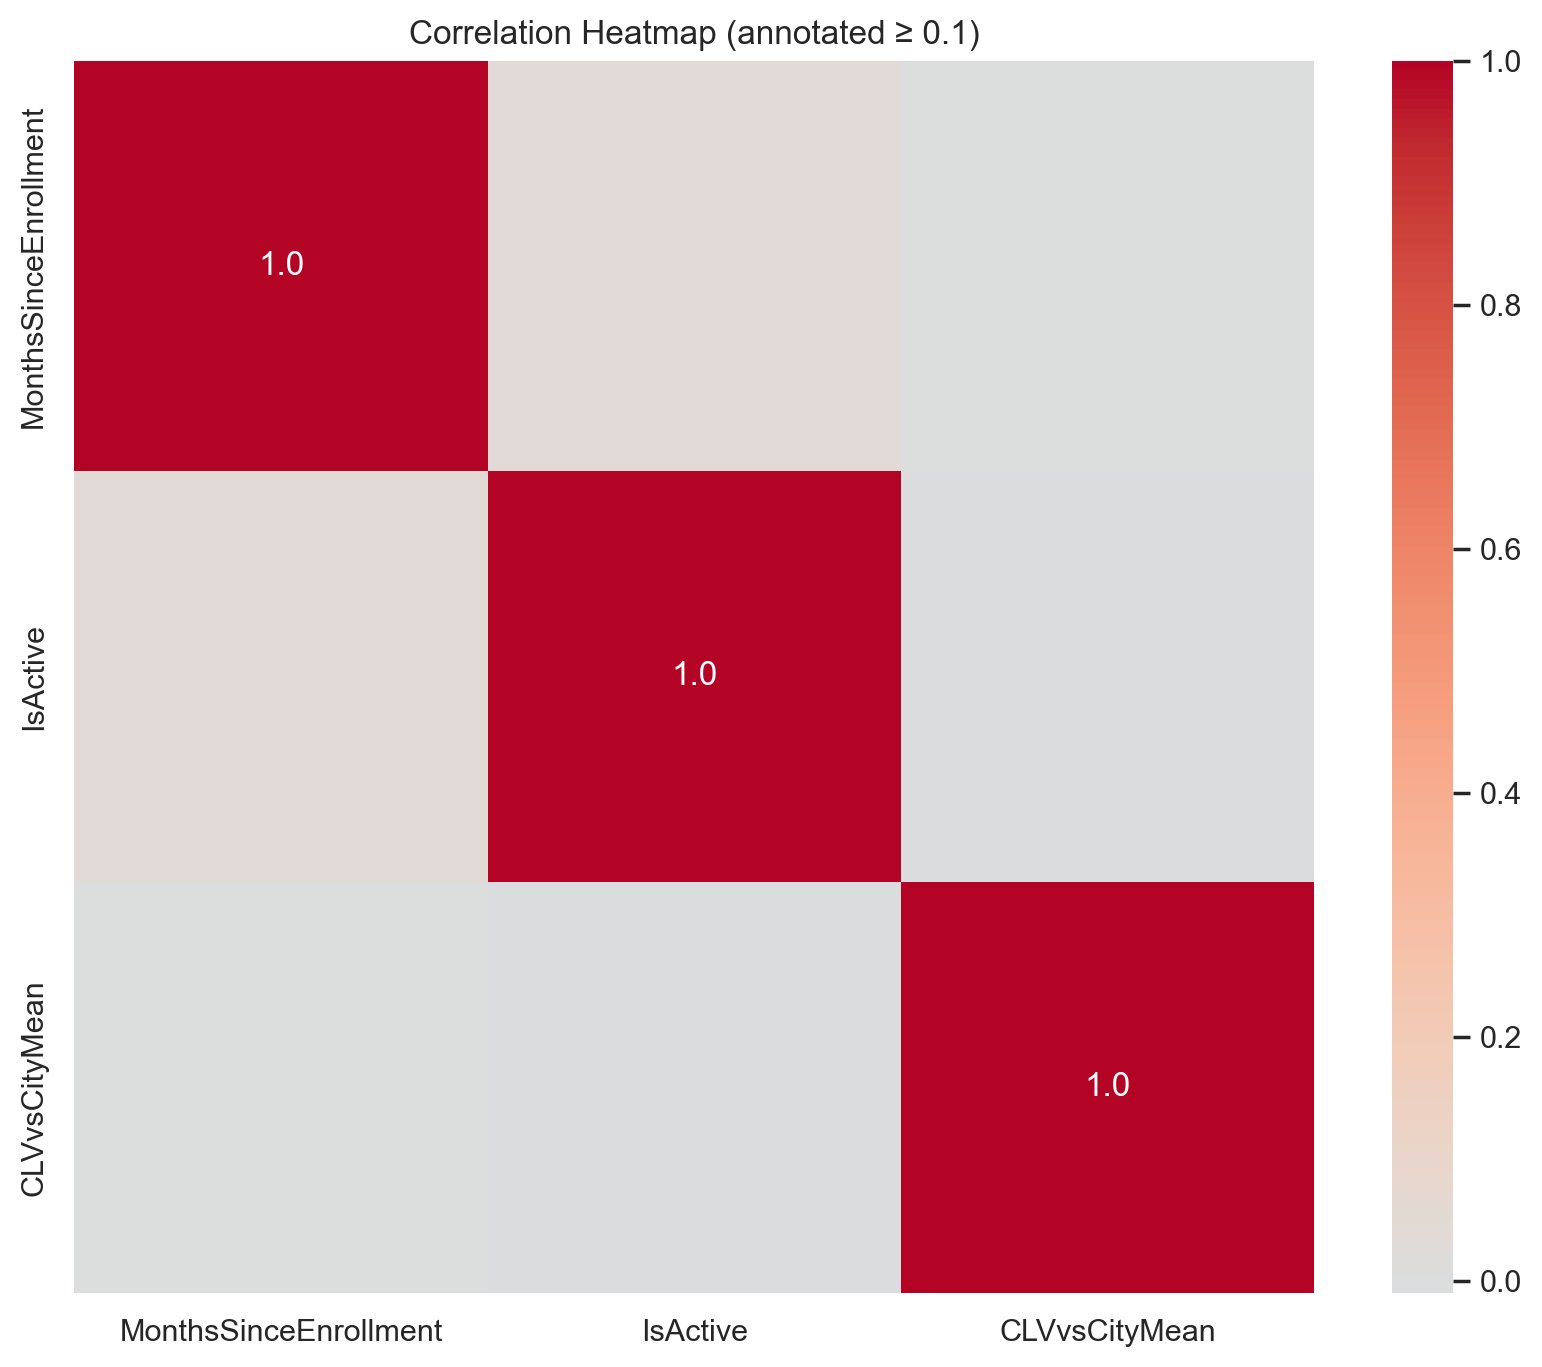

In [10]:
customerDB_new_cont = customerDB_new.select_dtypes(include=[np.number])

# Compute correlation matrix
corr = customerDB_new_cont.corr()

# Mask values > 0.6
mask_annot = np.abs(corr.values) >= 0.6
annot = np.where(mask_annot, np.round(corr.values, 2), "")

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(data=corr, annot=annot, fmt="", center=0, cmap="coolwarm")
plt.title("Correlation Heatmap (annotated ≥ 0.1)")
plt.show()


Since the correlation between all the numeric variables is very low, we have decided to keep them all.

## Feature Engineering with Merged Datasets

### Merge Datasets

In [11]:
# Create a second expanded flightsDB, keeping only one row per customer with aggregated features
flightsDB_expanded = flightsDB.merge(flightsDB_new, on='Loyalty#', how='right')

# Merge customerDB_expanded with flightsDB_expanded on Loyalty#
dfs_merged = customerDB_expanded.join(flightsDB_expanded, on="Loyalty#", how="left")

# Fill only numeric columns with 0
num_cols = dfs_merged.select_dtypes(include=['number']).columns
dfs_merged[num_cols] = dfs_merged[num_cols].fillna(0)

# Keep categorical NA values untouched

### Add Features

We have decided to add the following features to help us segment the customers later on.
- `FlightsPerMonthOfMembership:` Average number of flights a customer takes per month of membership. Calculated as TotalFlights / MonthsSinceEnrollment. Captures travel frequency relative to how long the customer has been in the program.

- `DistancePerCLV:` Total distance traveled by the customer normalized by their Customer Lifetime Value (CLV). Calculated as TotalDistanceKM / Customer Lifetime Value. Helps identify high-travel customers relative to their monetary value.

- `PointsRedeemedPerTotalCLV:` Loyalty points redeemed per dollar of CLV. Calculated as TotalPointsRedeemed / Customer Lifetime Value. Shows engagement efficiency in terms of spending vs. earned value.

- `RedemptionRateByLoyaltyStatus:` Customer’s points redemption relative to the average points redeemed for their loyalty tier. Calculated as TotalPointsRedeemed / mean(TotalPointsRedeemed per LoyaltyStatus). Captures how actively customers in a tier redeem points compared to peers.

- `DistanceTraveledByEducationLevel:` Customer’s total distance traveled relative to the average distance for their education level. Calculated as TotalDistanceKM / mean(TotalDistanceKM per Education group). Helps understand travel behavior patterns by education segment.


In [13]:
# Defensive helper for zero-division
def safe_div(numerator, denominator):
    return (numerator / denominator).replace([np.inf, -np.inf], 0).fillna(0)

# Flights per year of membership
dfs_merged["FlightsPerYearOfMembership"] = safe_div(
    dfs_merged["TotalFlights"],
    dfs_merged["MonthsSinceEnrollment"] / 12
)

# Distance per CLV
dfs_merged["DistancePerCLV"] = safe_div(
    dfs_merged["TotalDistanceKM"],
    dfs_merged["Customer Lifetime Value"]
)

# Points redeemed per CLV dollar
dollar_redeemed = flightsDB.groupby('Loyalty#')['DollarCostPointsRedeemed'].sum()
dfs_merged["PointsRedeemedPerCLVDollar"] = safe_div(
    dfs_merged["TotalPointsRedeemed"],
    dfs_merged.index.map(dollar_redeemed)
)

# Redemption rate by loyalty status
loyalty_points_mean = dfs_merged.groupby("LoyaltyStatus")["TotalPointsRedeemed"].transform("mean")
dfs_merged["RedemptionRateByLoyaltyStatus"] = safe_div(
    dfs_merged["TotalPointsRedeemed"],
    loyalty_points_mean
)

# Distance traveled by education level
edu_distance_mean = dfs_merged.groupby("Education")["TotalDistanceKM"].transform("mean")
dfs_merged["DistanceTraveledByEducationLevel"] = safe_div(
    dfs_merged["TotalDistanceKM"],
    edu_distance_mean
)

# Preview
dfs_merged.describe().T

,count,mean,min,25%,50%,75%,max,std
Latitude,16921.0,47.1745,42.984924,44.231171,46.087818,49.28273,60.721188,3.307971
Longitude,16921.0,-91.814768,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578,22.242429
Income,16921.0,37713.409787,0.0,0.0,34112.0,62375.0,99981.0,30378.754775
Customer Lifetime Value,16921.0,7981.015757,0.0,3971.35,5771.61,8936.82,83325.38,6864.608367
MonthsSinceEnrollment,16921.0,86.219674,46.833333,64.8,85.366667,107.1,131.133333,23.965966
IsActive,16921.0,0.863483,0.0,1.0,1.0,1.0,1.0,0.343347
CLVvsCityMean,16921.0,0.0,-6767.170102,-3996.415625,-2142.902095,962.220831,75236.176746,6853.83106
Loyalty#,16921.0,550197.393771,100011.0,326823.0,550896.0,772438.0,999999.0,259251.503597
Year,16921.0,1141.979138,0.0,0.0,2019.0,2020.0,2021.0,1001.376131
Month,16921.0,3.667809,0.0,0.0,2.0,7.0,12.0,4.144635


### Select Created Features

Analyse if it makes sense to keep all the features

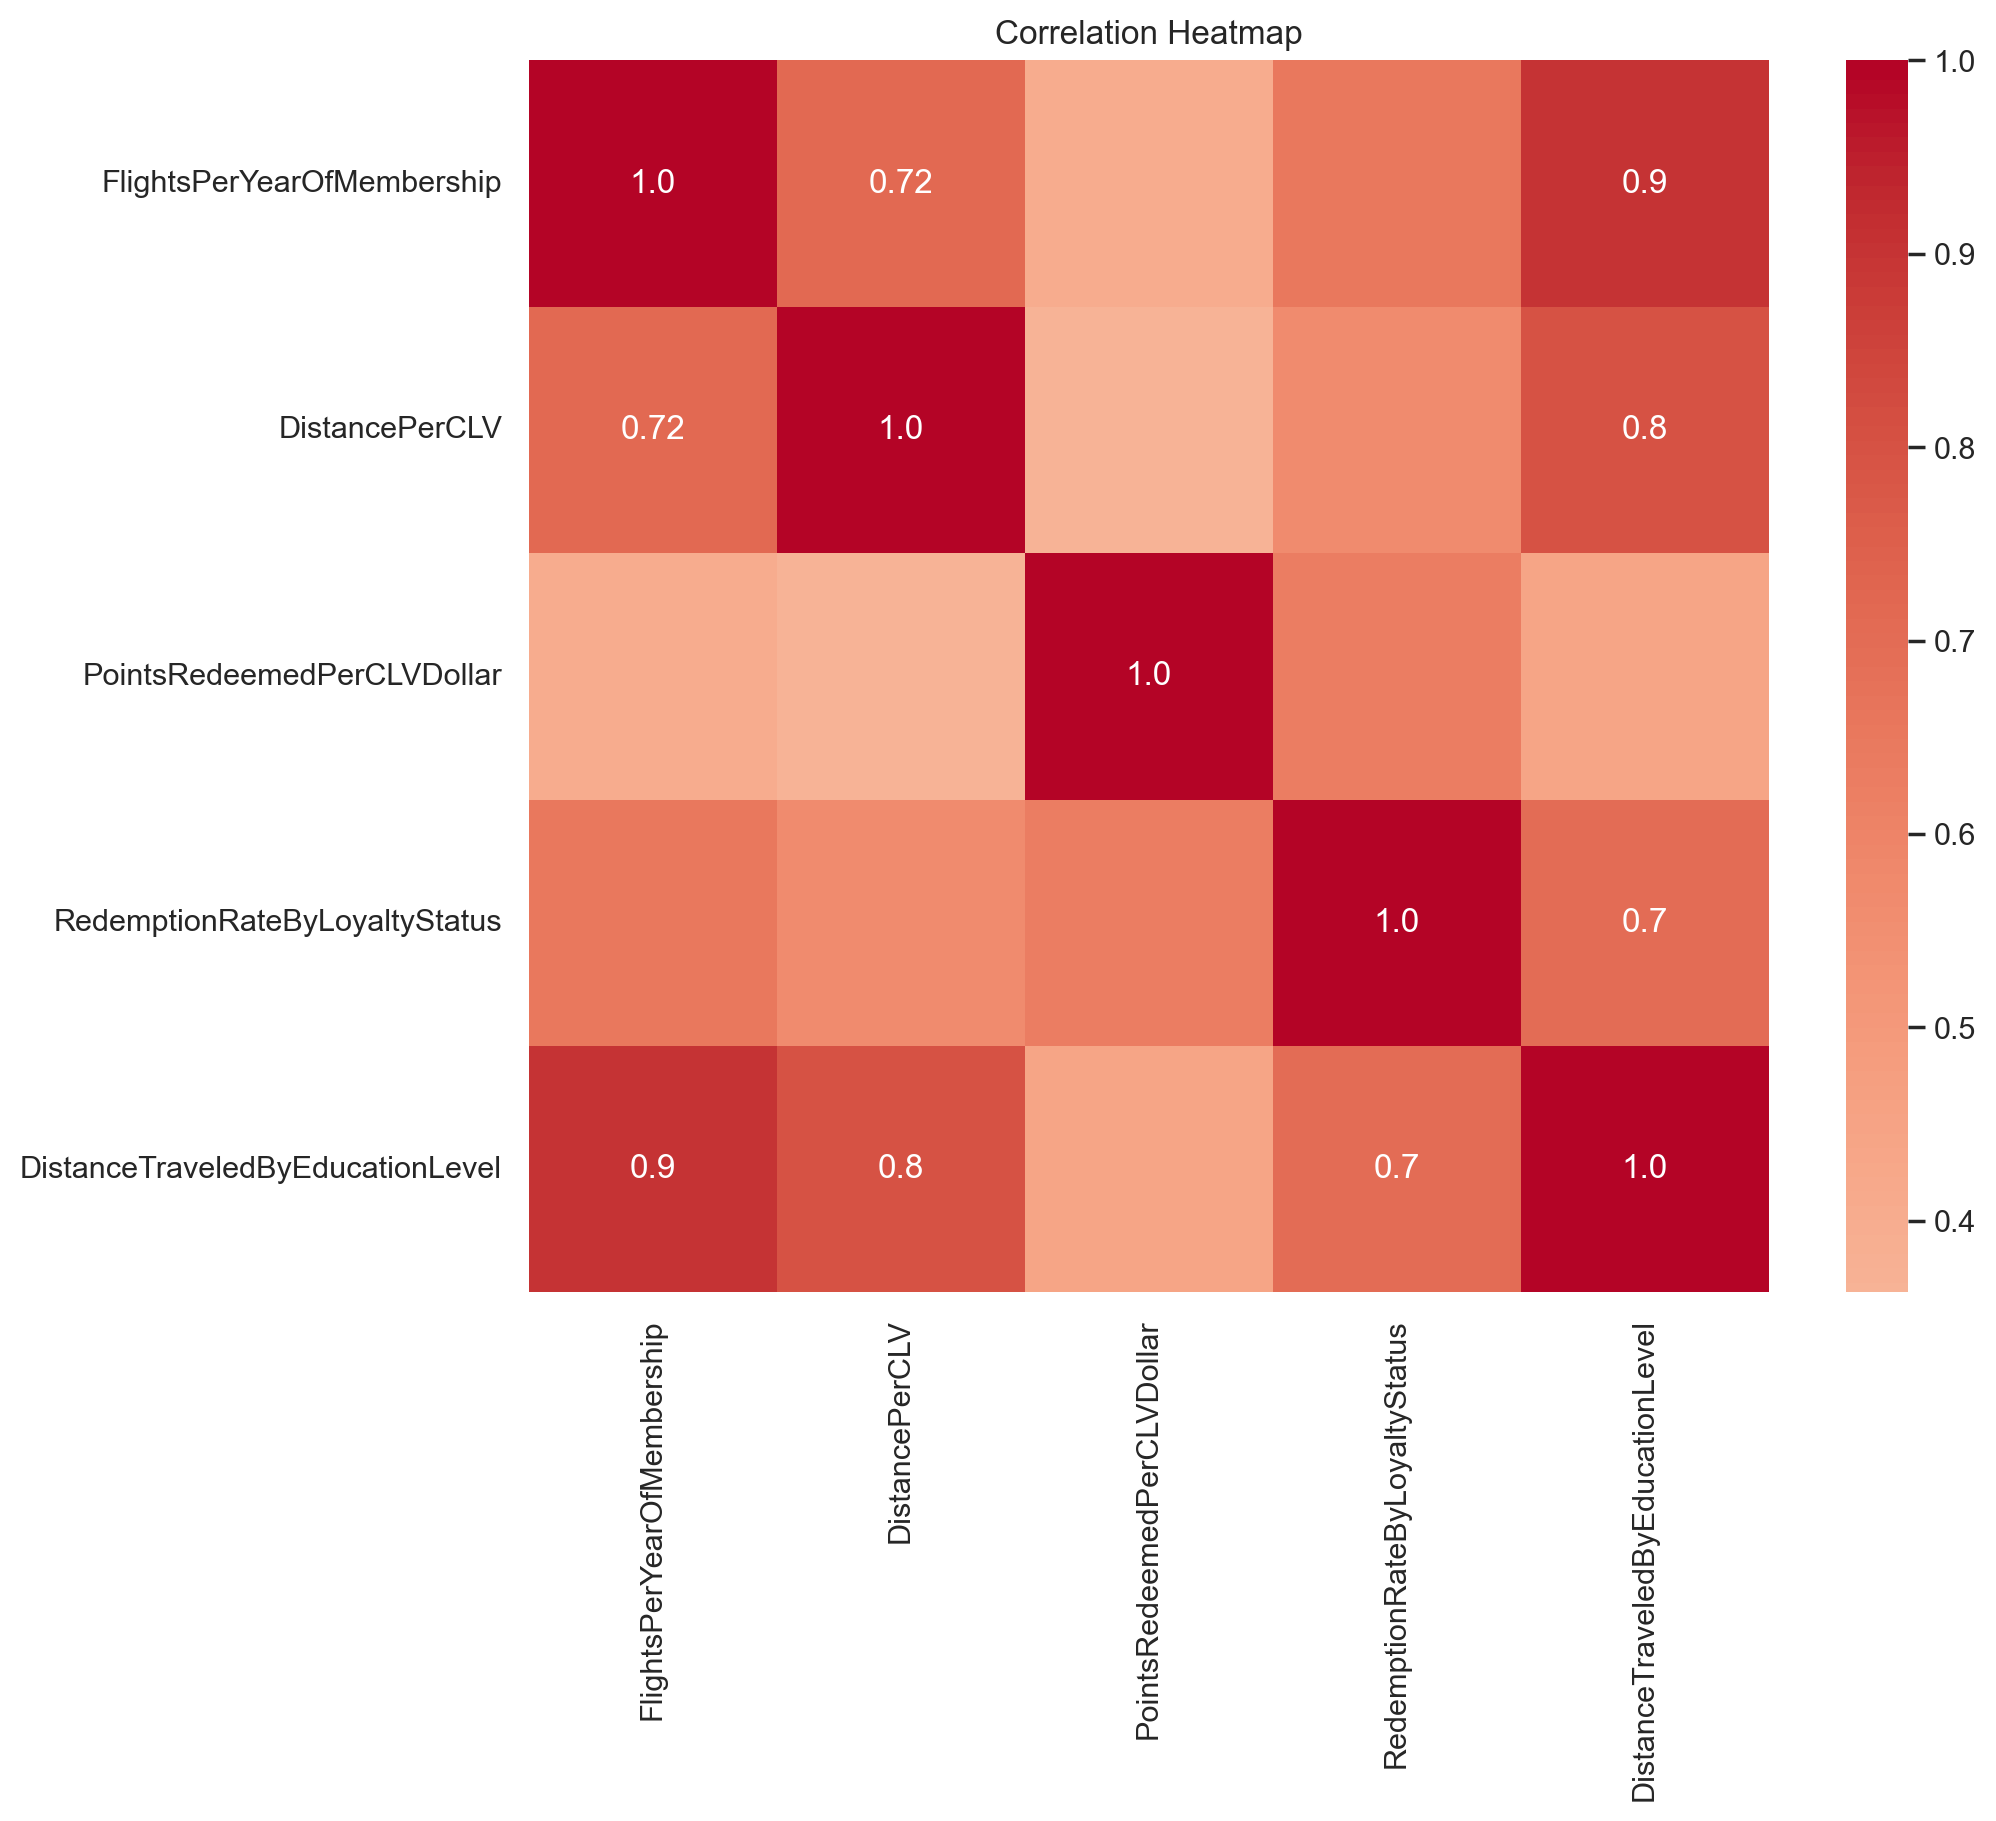

In [15]:
dfs_merged_new = dfs_merged[['FlightsPerYearOfMembership', 
                             'DistancePerCLV', 
                             'PointsRedeemedPerCLVDollar', 
                             'RedemptionRateByLoyaltyStatus', 
                             'DistanceTraveledByEducationLevel']]

# Compute correlation matrix
corr = dfs_merged_new.corr()

# Mask values
mask_annot = np.abs(corr.values) >= 0.7
annot = np.where(mask_annot, np.round(corr.values, 2), "")

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(data=corr, annot=annot, fmt="", center=0, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Analysing the correlation matrix:
- `FlightsPerYearOfMembership & DistanceTraveledByEducationLevel (0.9):`This is a very strong correlation. Likely, customers who fly more also travel longer distances, and education level might be correlated with flying habits possibly because frequent flyers are often business travelers.

- `DistancePerCLV & DistanceTraveledByEducationLevel (0.8):` Customers with higher travel distances for their CLV also have higher distances associated with their education level, suggesting a socioeconomic influence on travel patterns once again.

- `FlightsPerYearOfMembership & DistancePerCLV & DistanceTraveledByEducationLevel:` All three combinations reinforce that flight frequency, travel distance, and socioeconomic status are interlinked, likely capturing overlapping behavioral patterns in high-value customer groups.

- `FlightsPerYearOfMembership & DistancePerCLV (0.72):` Frequent fliers are likely to accumulate greater distance per unit of customer lifetime value (CLV).

- `RedemptionRateByLoyaltyStatus & DistanceTraveledByEducationLevel (0.7):` Higher educational status may correlate with strategic redemption, as well-educated customers could be more aware of program benefits and optimize point/redemption behavior.

To conclude, we chose to **keep only FlightsPerYearOfMembership and RedemptionRateByLoyaltyStatus.**

In [16]:
dfs_merged = dfs_merged.drop(columns=[
    'DistancePerCLV',
    'PointsRedeemedPerCLVDollar',
    'DistanceTraveledByEducationLevel'])

dfs_merged_new = dfs_merged_new.drop(columns=[
    'DistancePerCLV',
    'PointsRedeemedPerCLVDollar',
    'DistanceTraveledByEducationLevel'])

dfs_merged_new.columns

Index(['FlightsPerYearOfMembership', 'RedemptionRateByLoyaltyStatus'], dtype='object')

## Summary of Engineered Features

To summarise, we chose to keep:

FLIGHTSDB

- `PointsRedemptionRatio`
- `TotalFlightWithCompanionRatio`
- `Recency`
- `DistancePerFlight`

CUSTOMERSDB

- `IncomeBins`
- `HouseholdType`
- `MonthsSinceEnrollment`
- `CLVBins`
- `CLVvsCityMean`

MERGED DATASETS

- `FlightsPerYearOfMembership`
- `RedemptionRateByLoyaltyStatus`

# Engineered Features' Visualisations

## FlightsDB

Update flightsDB_new with only the features that we kept.

In [17]:
flightsDB_new = flightsDB_new.drop(columns=[
    'TotalFlights',
    'TotalFlightsWithCompanions',
    'TotalDistanceKM',
   'TotalPointsAccumulated'
], errors='ignore')

flightsDB_new.head()

,Loyalty#,TotalPointsRedeemed,FlightsVariance,PointsRedemptionRatio,TotalFlightWithCompanionRatio,Recency,DistancePerFlight
0,100018,20562.8,21.338944,0.387873,0.214876,0,2306.350587
1,100102,18760.6,27.233611,0.553345,0.234962,0,1369.053694
2,100140,4896.0,24.899492,0.113353,0.250000,1,1992.761993
3,100214,12908.6,16.253611,0.354109,0.175423,0,3246.675868
4,100272,10891.4,32.355492,0.253564,0.284871,1,2304.884657


### Histograms

Create feature with all engineered features and another one with just the continuous ones.

In [18]:
flightsDB_new_cont = flightsDB_new[['PointsRedemptionRatio','TotalFlightWithCompanionRatio','Recency', 'DistancePerFlight']]
flightsDB_new_cont.head()

,PointsRedemptionRatio,TotalFlightWithCompanionRatio,Recency,DistancePerFlight
0,0.387873,0.214876,0,2306.350587
1,0.553345,0.234962,0,1369.053694
2,0.113353,0.250000,1,1992.761993
3,0.354109,0.175423,0,3246.675868
4,0.253564,0.284871,1,2304.884657


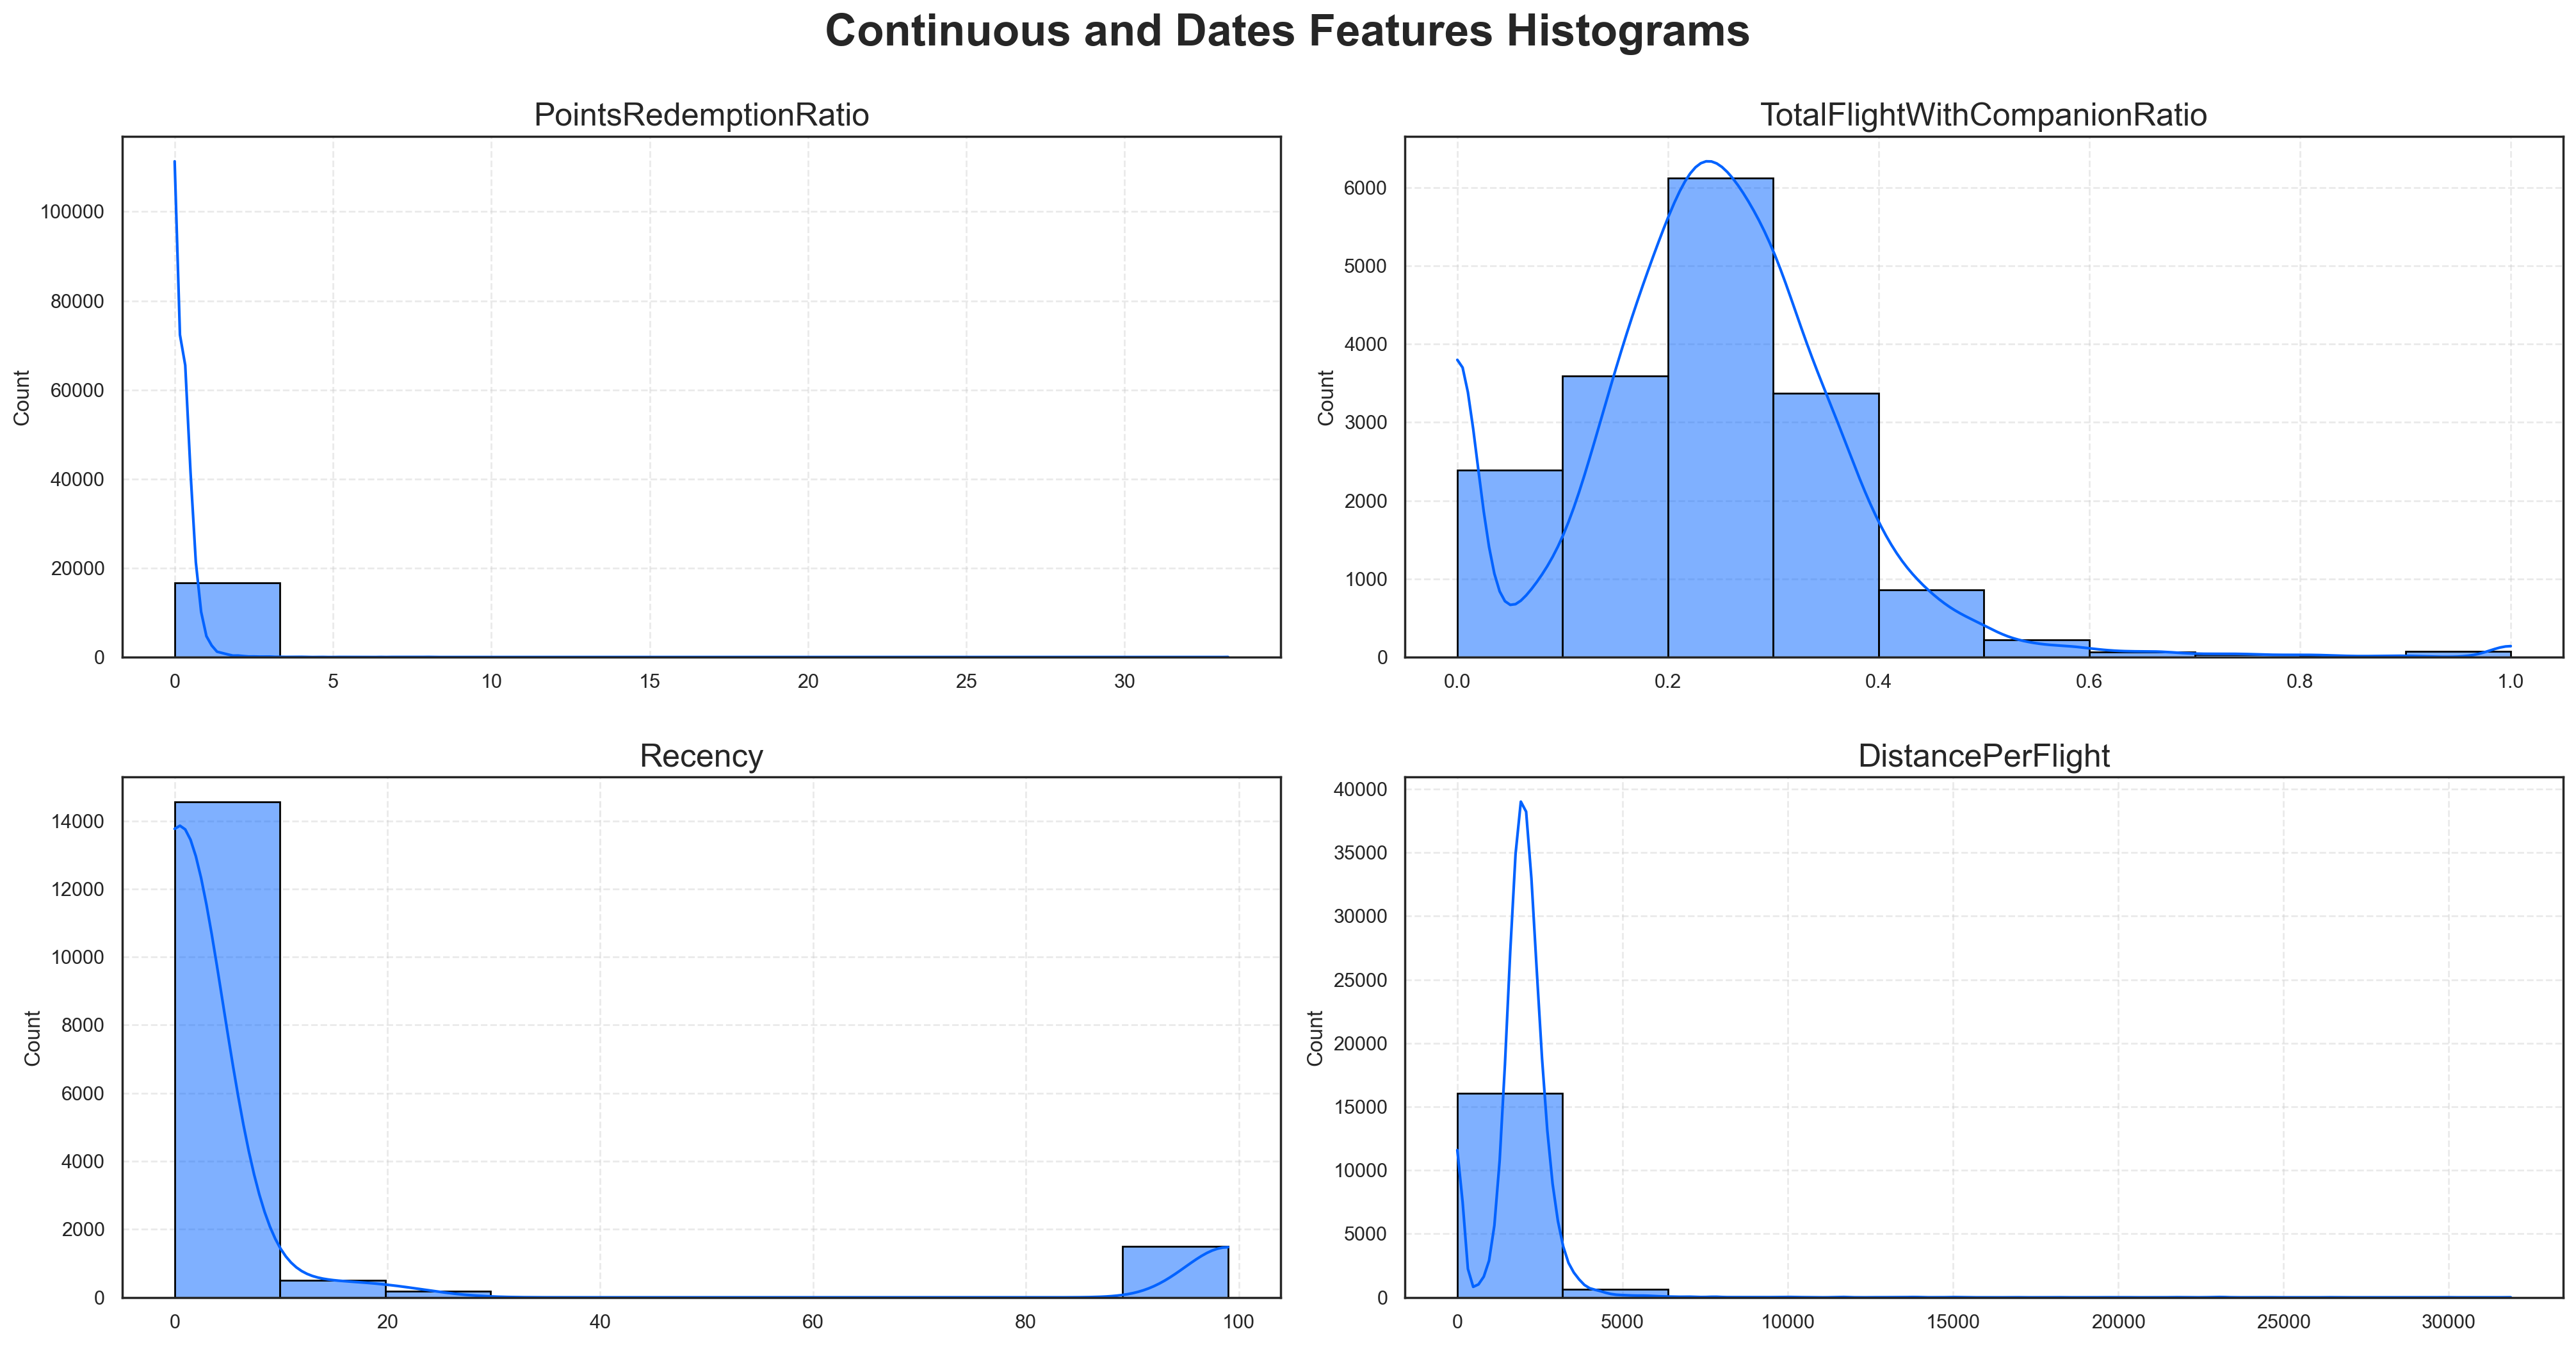

In [19]:
#To plot histograms we will use continuous and date features that were identified before

# Set minimal style
sns.set_style("white") # increase contrast

# Create a canvas for the metric features
fig, axes = plt.subplots(2, # set number of rows
                         2, 
                         figsize=(20, 10),
                         constrained_layout=True) # Adjust automatically spacing between subplot and labels 

# Increase vertical space between rows
fig.set_constrained_layout_pads(h_pad=.2)

# Plot the data
# Iterate across axes objects and associate each histogram:
for ax, feat in zip(axes.flatten(), flightsDB_new_cont):
    sns.histplot(flightsDB_new[feat],
                 bins=10,
                 kde=(feat in flightsDB_new_cont), #smooth line only for continuous features
                 ax=ax,
                 color="#0062FF",
                 edgecolor="black")
    ax.set_title(feat, fontsize=18)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_xlabel("")

# Layout
# Add title, make it bigger and bold and add space between title and first row of plots
plt.suptitle("Continuous and Dates Features Histograms", 
             fontsize = 25, fontweight="bold", y=1.05)

# Create the folder '../figures/eda' if it doesn't already exist
os.makedirs(os.path.join('..', 'figures', 'eda'), exist_ok=True)
    
# Save figure to a png file in the folder created before
plt.savefig(os.path.join('..', 'figures', 'eda', 'numeric_features_histograms.png'), dpi=200)

# Show plot
plt.show()

- `PointsRedemptionRatio:` Most customers redeem a small fraction of their points, with the distribution sharply skewed toward low ratios and very few high redeemers present.
- `TotalFlightWithCompanionRatio:` The majority of travelers have low companion ratios, concentrating around 0.2–0.3, but a small minority frequently travel with companions.
- `Recency:` Customer activity is heavily biased towards recent periods, though a distant subgroup has not transacted for a long time, suggesting few inactive accounts among many actives.
- `DistancePerFlight:` Most customers take short flights, but the distribution has a pronounced long tail, revealing a smaller group often undertaking much longer journeys.

### Boxplot

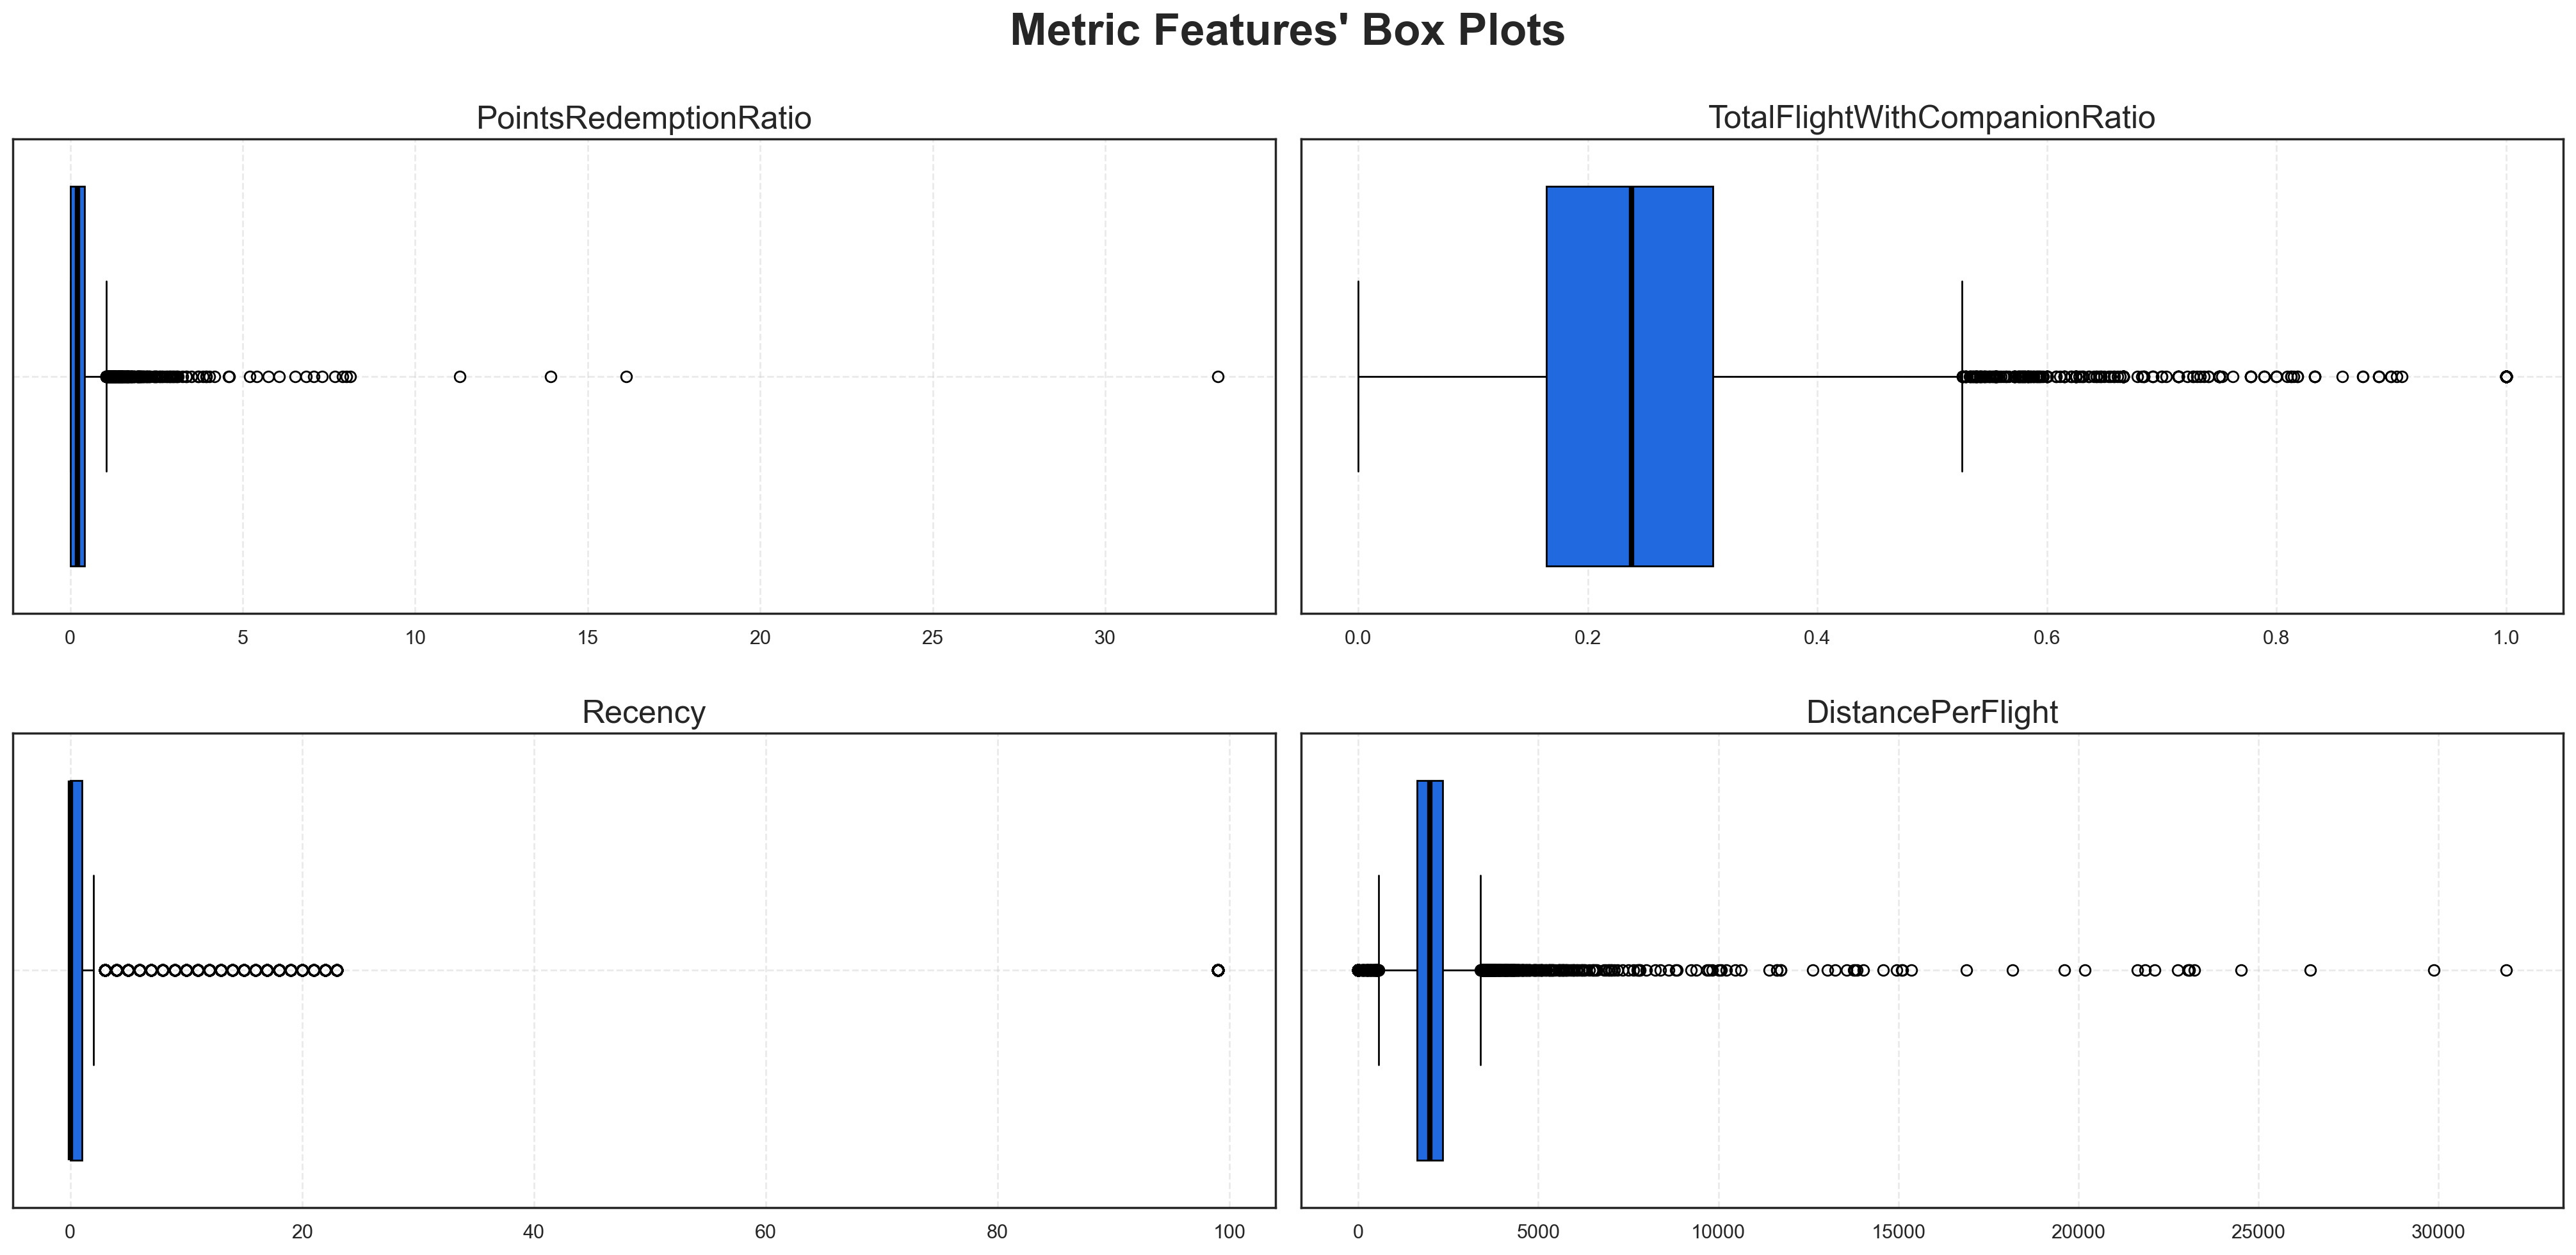

In [20]:
# Prepare figure. Create individual axes where each histogram will be placed
fig, axes = plt.subplots(2, 
                         2, 
                         figsize=(20, 10),
                         constrained_layout=True) # Adjust automatically spacing between subplot and labels 

# Increase vertical space between rows
fig.set_constrained_layout_pads(h_pad=.2)

# Plot data
# Iterate across axes objects and associate each box plot:
for ax, feat in zip(axes.flatten(), flightsDB_new_cont): 
    sns.boxplot(x=flightsDB_new_cont[feat], ax=ax,
                # Set inside color to blue
                color="#0062FF",
                # Set line colors to black
                boxprops=dict(edgecolor="black"),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                medianprops=dict(color="black", linewidth=3),
                flierprops=dict(markeredgecolor="black"))
    
    # Put grid with low opacity and dashed line so it's visible, but not distracting
    ax.grid(True, linestyle="--", alpha=0.4)

    # Put title of each graph with bigger font
    ax.set_title(feat, fontsize=18)

    # Hide x label since we already have the boxlplot title at the top
    ax.set_xlabel("")
    
# Layout
# Add title and make it bigger
plt.suptitle("Metric Features' Box Plots", 
             fontsize = 25, fontweight="bold")

# Create the folder '../figures/eda' if it doesn't already exist
os.makedirs(os.path.join('..', 'figures', 'eda'), exist_ok=True)

# Save figure to a png file in the folder created before
plt.savefig(os.path.join('..', 'figures', 'eda', 'numeric_features_boxplots.png'), dpi=200)

# Show plot
plt.show()

From the boxplots we take these conclusions:
- `PointsRedemptionRatio:` The redemption ratio is tightly concentrated between 0 and 1 for most, though there are several outliers redeeming more points than the ones that were accumulated. This is an error in the data that might be costly to the company.

- `TotalFlightWithCompanionRatio:` The majority of customers have a companion ratio between 0.1 and 0.3, with a few extreme outliers close to 1, showing that only a small subset consistently flies with companions.​

- `Recency:` Most customers have low recency scores, suggesting frequent engagement, but a substantial tail with large values reveals a segment of rarely active or lapsed users.​

- `DistancePerFlight:` Short-haul flights dominate, yet several significant outliers travel over 10,000 km per flight, indicating a distinct group of long-distance travelers within the customer base.

### Scatter Plots

To assess correlation, we have selected a few pairs of features that we thought could bring additional insights. 

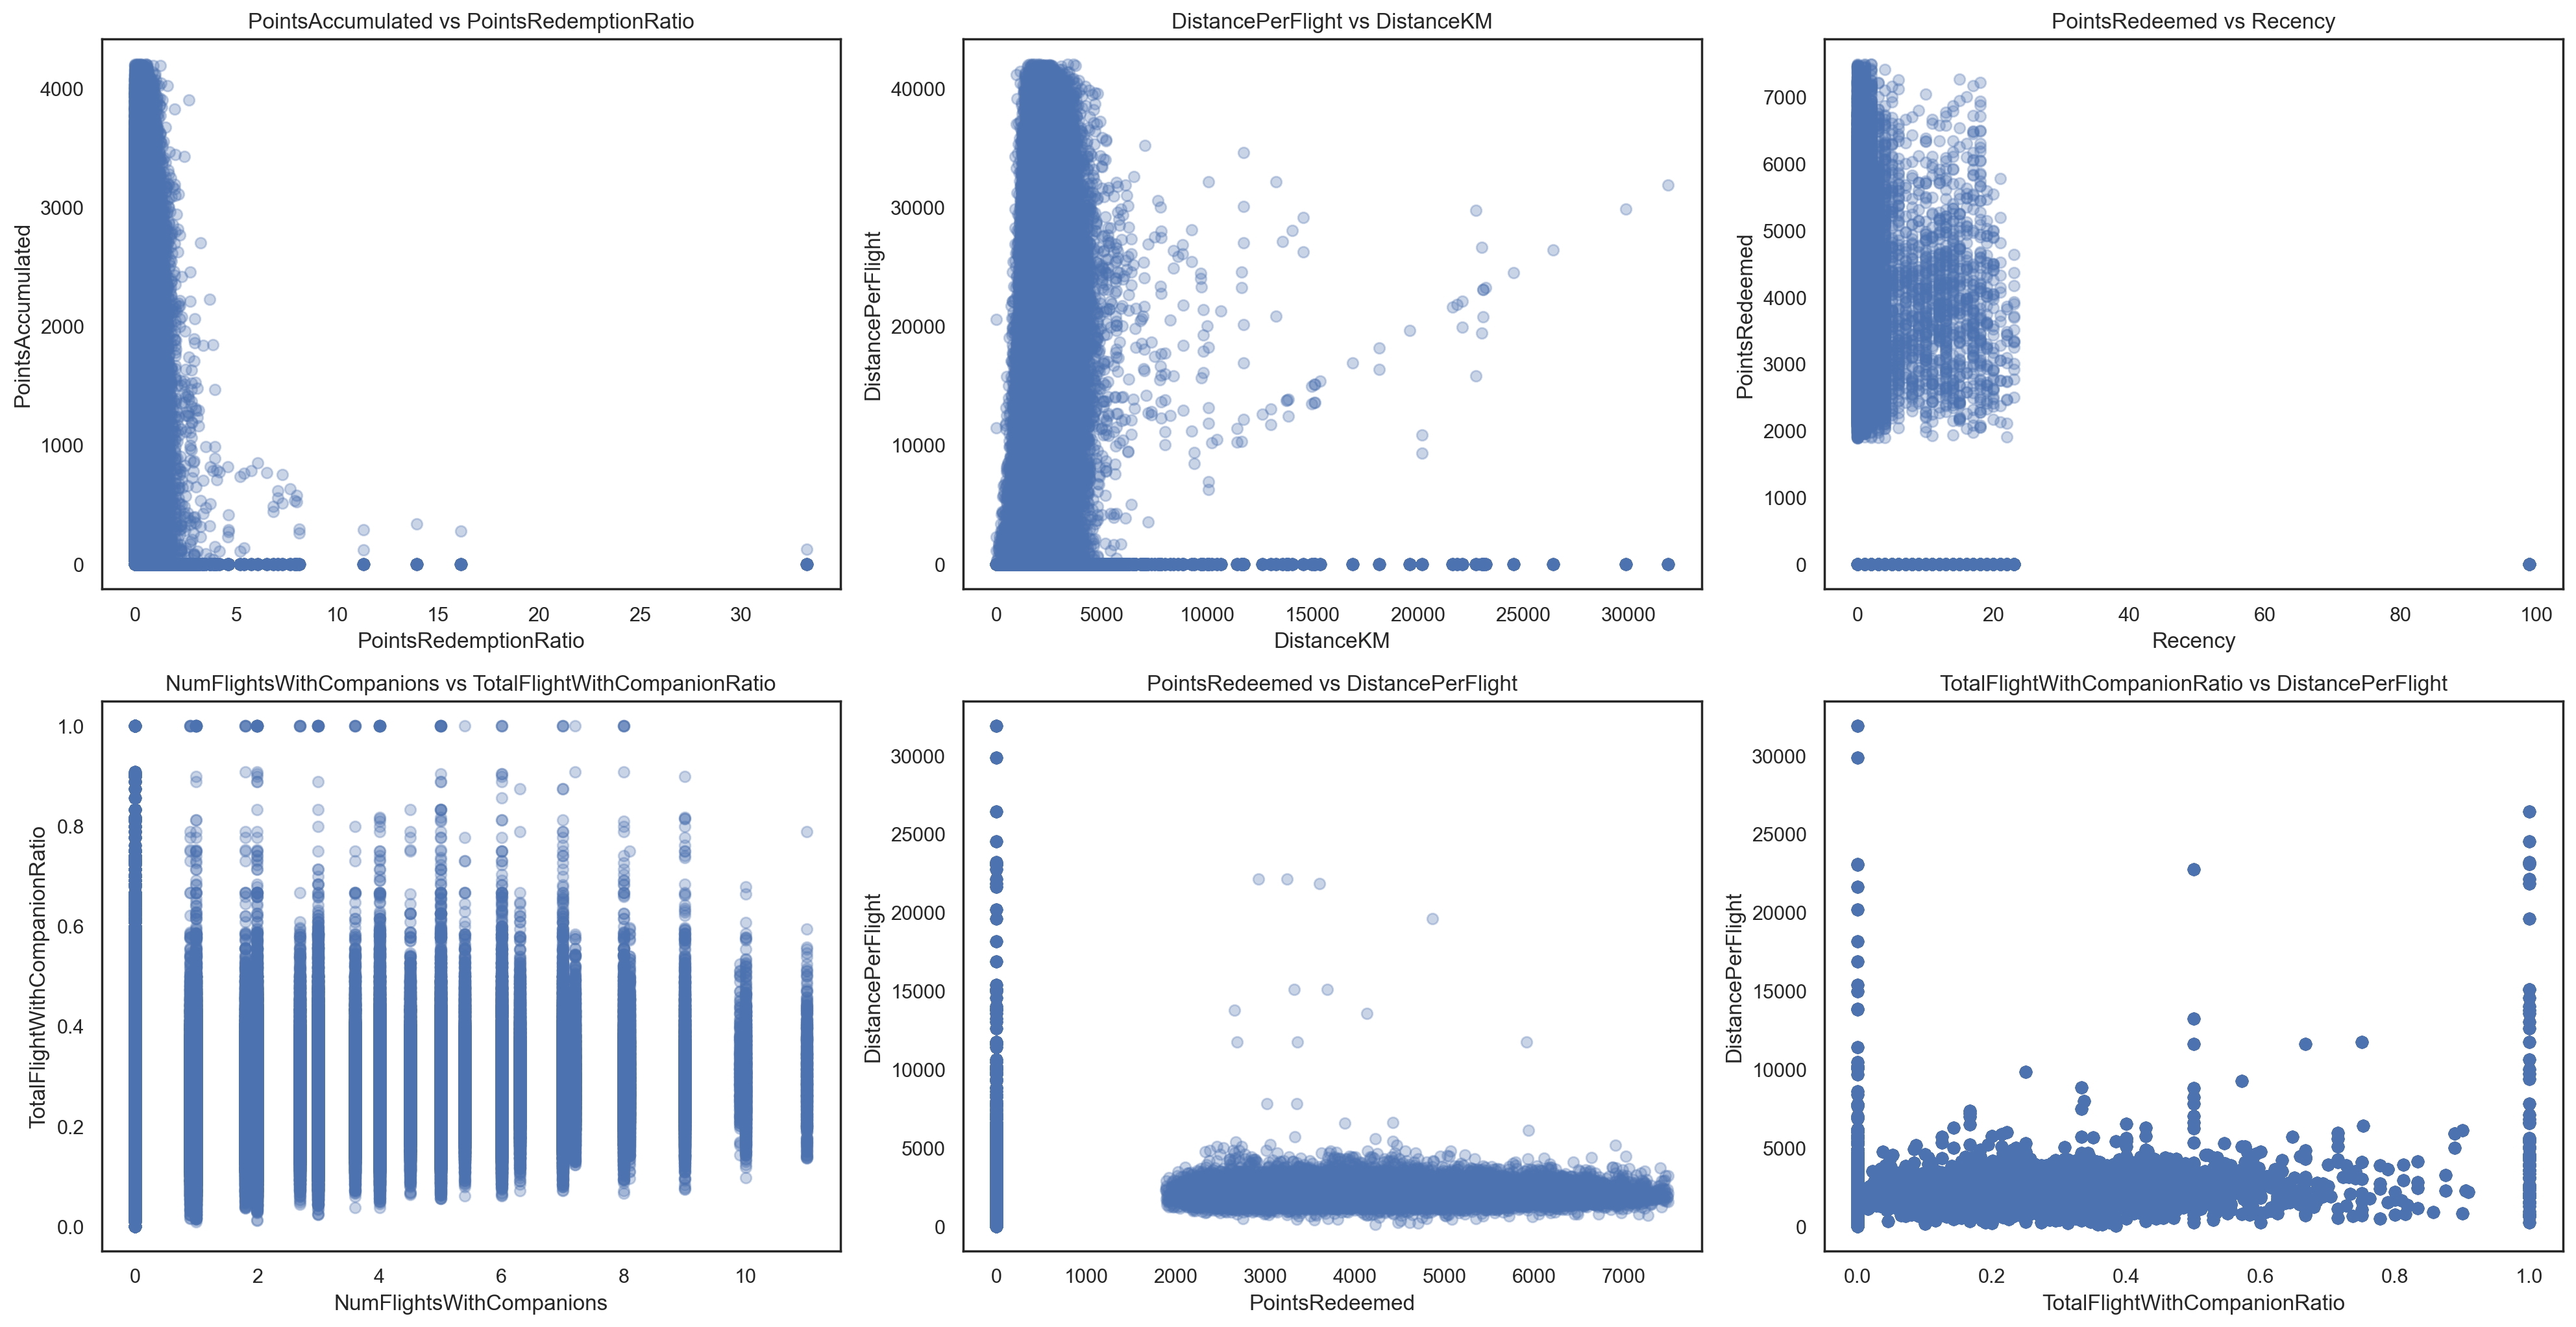

In [22]:
# Scatterplots for selected pairs
plt.figure(figsize=(20, 15))

# 1. PointsAccumulated vs PointsRedemptionRatio
plt.subplot(3, 3, 1)
plt.scatter(flightsDB_expanded["PointsRedemptionRatio"], flightsDB_expanded["PointsAccumulated"], alpha=0.3)
plt.title("PointsAccumulated vs PointsRedemptionRatio")
plt.xlabel("PointsRedemptionRatio")
plt.ylabel("PointsAccumulated")

# 2. DistanceKM vs DistancePerFlight
plt.subplot(3, 3, 2)
plt.scatter(flightsDB_expanded["DistancePerFlight"], flightsDB_expanded["DistanceKM"], alpha=0.3)
plt.title("DistancePerFlight vs DistanceKM")
plt.xlabel("DistanceKM")
plt.ylabel("DistancePerFlight")

# 3. PointsRedeemed vs Recency
plt.subplot(3, 3, 3)
plt.scatter(flightsDB_expanded["Recency"], flightsDB_expanded["PointsRedeemed"], alpha=0.3)
plt.title("PointsRedeemed vs Recency")
plt.xlabel("Recency")
plt.ylabel("PointsRedeemed")

# 4. NumFlightsWithCompanions vs TotalFlightWithCompanionRatio
plt.subplot(3, 3, 4)
plt.scatter(flightsDB_expanded["NumFlightsWithCompanions"], flightsDB_expanded["TotalFlightWithCompanionRatio"], alpha=0.3)
plt.title("NumFlightsWithCompanions vs TotalFlightWithCompanionRatio")
plt.xlabel("NumFlightsWithCompanions")
plt.ylabel("TotalFlightWithCompanionRatio")

# 5. PointsRedeemed vs DistancePerFlight
plt.subplot(3, 3, 5)
plt.scatter(flightsDB_expanded["PointsRedeemed"], flightsDB_expanded["DistancePerFlight"], alpha=0.3)
plt.title("PointsRedeemed vs DistancePerFlight")
plt.xlabel("PointsRedeemed")
plt.ylabel("DistancePerFlight")

# 6. DistancePerFlight vs TotalFlightWithCompanionRatio
plt.subplot(3, 3, 6)
plt.scatter(flightsDB_expanded["TotalFlightWithCompanionRatio"], flightsDB_expanded["DistancePerFlight"], alpha=0.3)
plt.title("TotalFlightWithCompanionRatio vs DistancePerFlight")
plt.xlabel("TotalFlightWithCompanionRatio")
plt.ylabel("DistancePerFlight")

plt.tight_layout()
plt.show()


Conclusions:
- `PointsAccumulated vs PointsRedemptionRatio:` It is difficult to take any conclusions, but we can see that customers who accumulate the most points have slightly lower redemption ratios than the ones that do not accumulate as much.

- `DistancePerFlight vs DistanceKM:` Again, there are not many conclusions to take, but we can see a light linear correlation between the two features for a small number of observations.

- `PointsRedeemed vs Recency:` Most point redemptions occur among recently active customers, but there is a segment with high redemption and long recency, indicating potentially lapsed users.

- `NumFlightsWithCompanions vs TotalFlightWithCompanionRatio:` Ratios stay in between 0.1 and 0.6 for most observations, regardless of the number of flights, but for customers with low numbers of flights the ratio tends to be higher.

- `PointsRedeemed vs DistancePerFlight:` Higher point redeemers may be associated with smaller distances per flight, indicating points are more often used on small-distance journeys.

- `TotalFlightWithCompanionRatio vs DistancePerFlight:` The companion ratio does not strongly predict flight distance, but there are groups who both travel together and take longer trips.

## CustomerDB

### Histograms

We will compare the new metric features MonthsSinceEnrollment and CLVvsCityMean.

In [25]:
customerDB_new_cont = customerDB_new.select_dtypes(include=[np.number]).drop(columns=['IsActive'])
customerDB_new_categ = customerDB_new[['IncomeBins', 'HouseholdType', 'CLVBins', 'IsActive']]

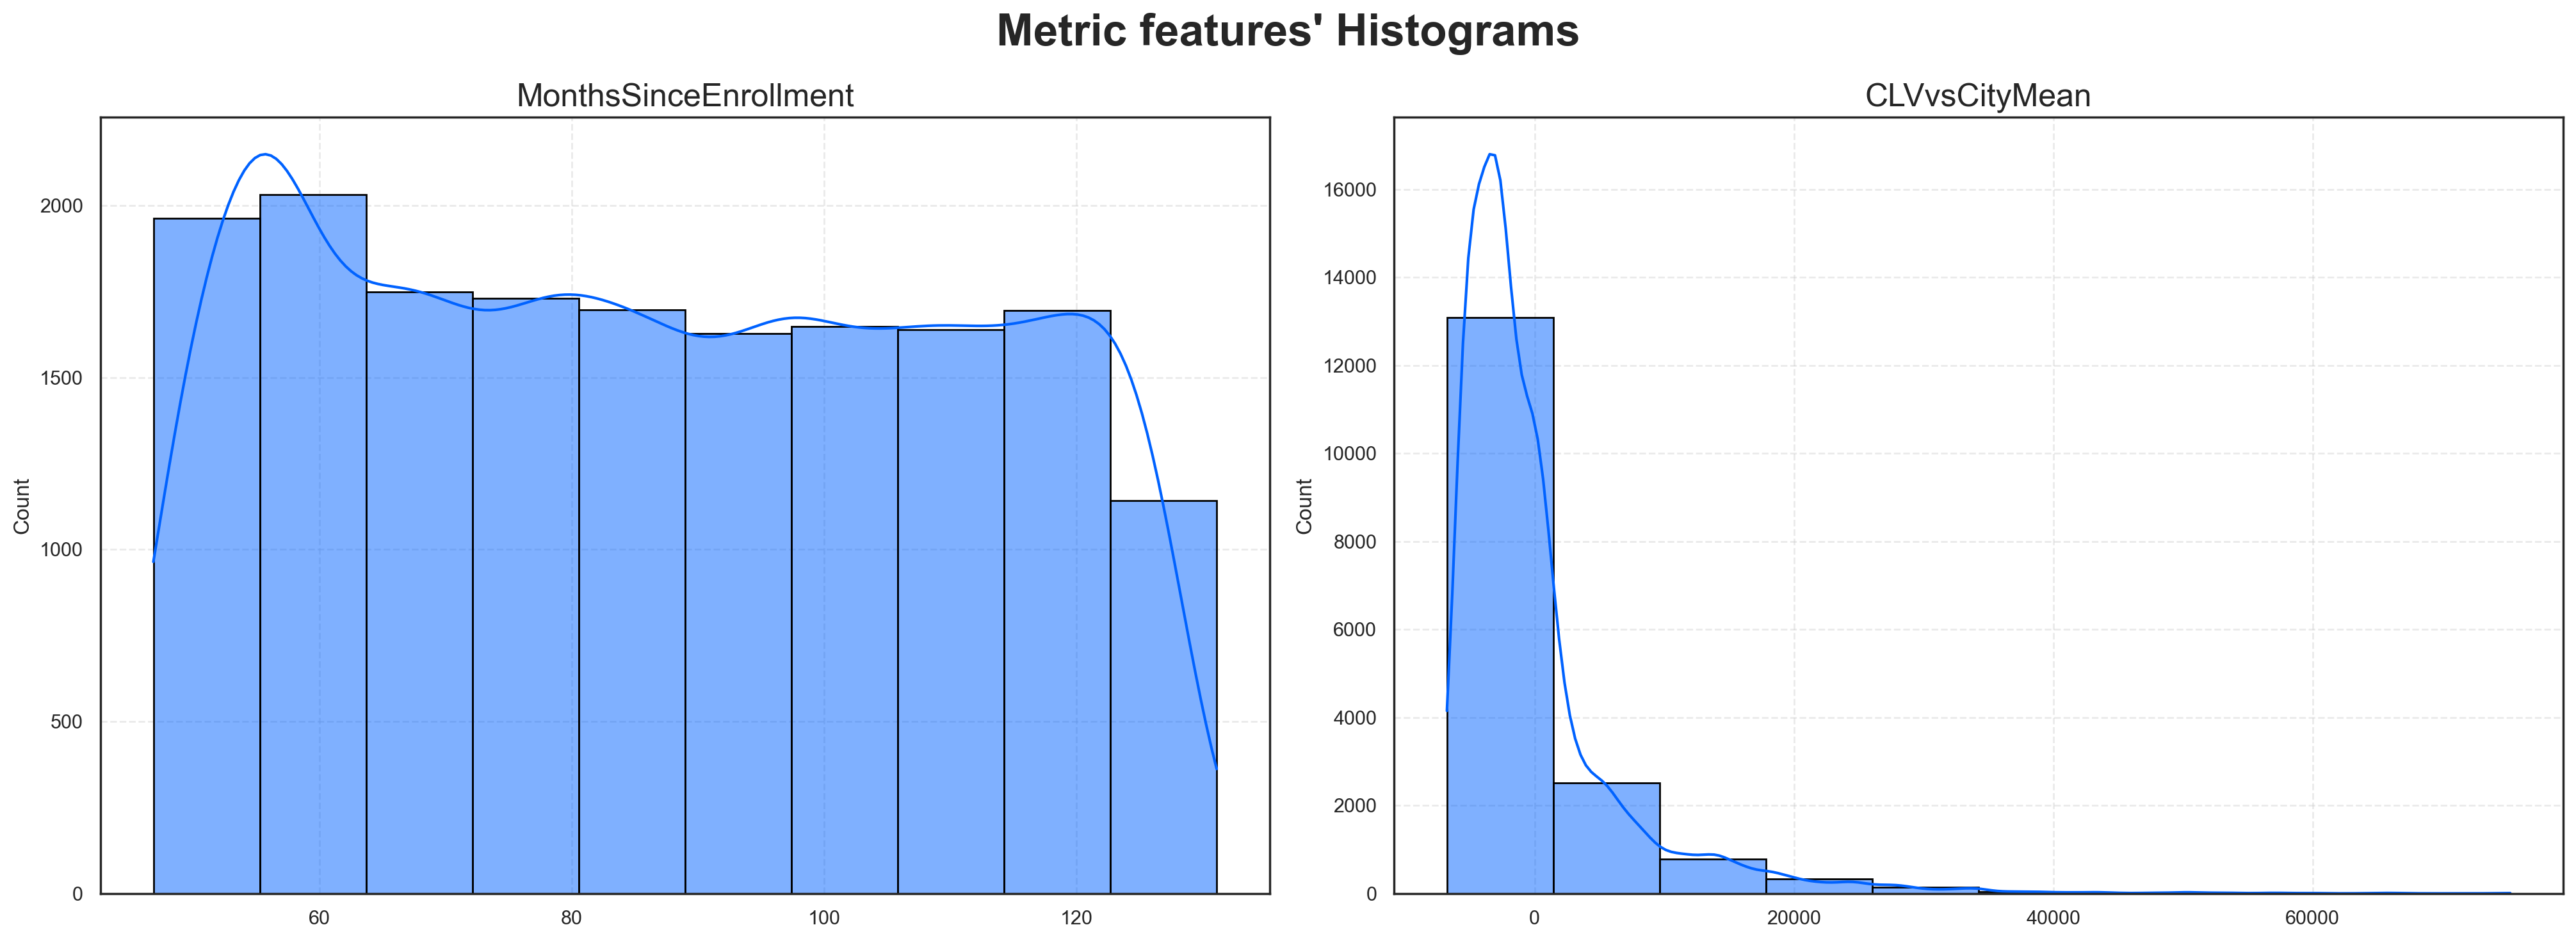

In [26]:
# Set number of rows and columns
sp_rows_CDB_new = 1
sp_cols_CDB_new = 2

# Set style
sns.set_style("white") # increase contrast

# Create figure
fig, axes = plt.subplots(sp_rows_CDB_new,
                         sp_cols_CDB_new,
                         figsize=(20, 7),
                         constrained_layout=True)

# Additional spacing between rows
fig.set_constrained_layout_pads(h_pad=.2)

# Plot data
for ax, feat in zip(axes.flatten(), customerDB_new_cont):
    
    sns.histplot(customerDB_new_cont[feat],
                 bins=10,
                 kde=(feat in customerDB_new_cont.columns), #smooth line only for continuous features
                 ax=ax,
                 color="#0062FF",
                 edgecolor="black")
    
    ax.set_title(feat, fontsize=18)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_xlabel("")

# Global title
plt.suptitle("Metric features' Histograms",
             fontsize=25,
             fontweight="bold",
             y=1.05)

# Save figure
os.makedirs(os.path.join('..', 'figures', 'eda'), exist_ok=True)
fig.savefig(os.path.join('..', 'figures', 'eda', 'customerDB_new_features.png'),
            dpi=200)

# display output
plt.show()


Conclusions:

- `MonthsSinceEnrollment:` Customer tenure is evenly distributed with most customers enrolled between 50 and 130 months ago, indicating a stable acquisition rate over time and no heavy skew toward new or old members.

- `CLVvsCityMean:` The majority of customers have a customer lifetime value (CLV) near their city’s average, but there is a pronounced long tail showing a small segment with dramatically higher CLV than the norm, highlighting valuable outliers.

### Boxplots

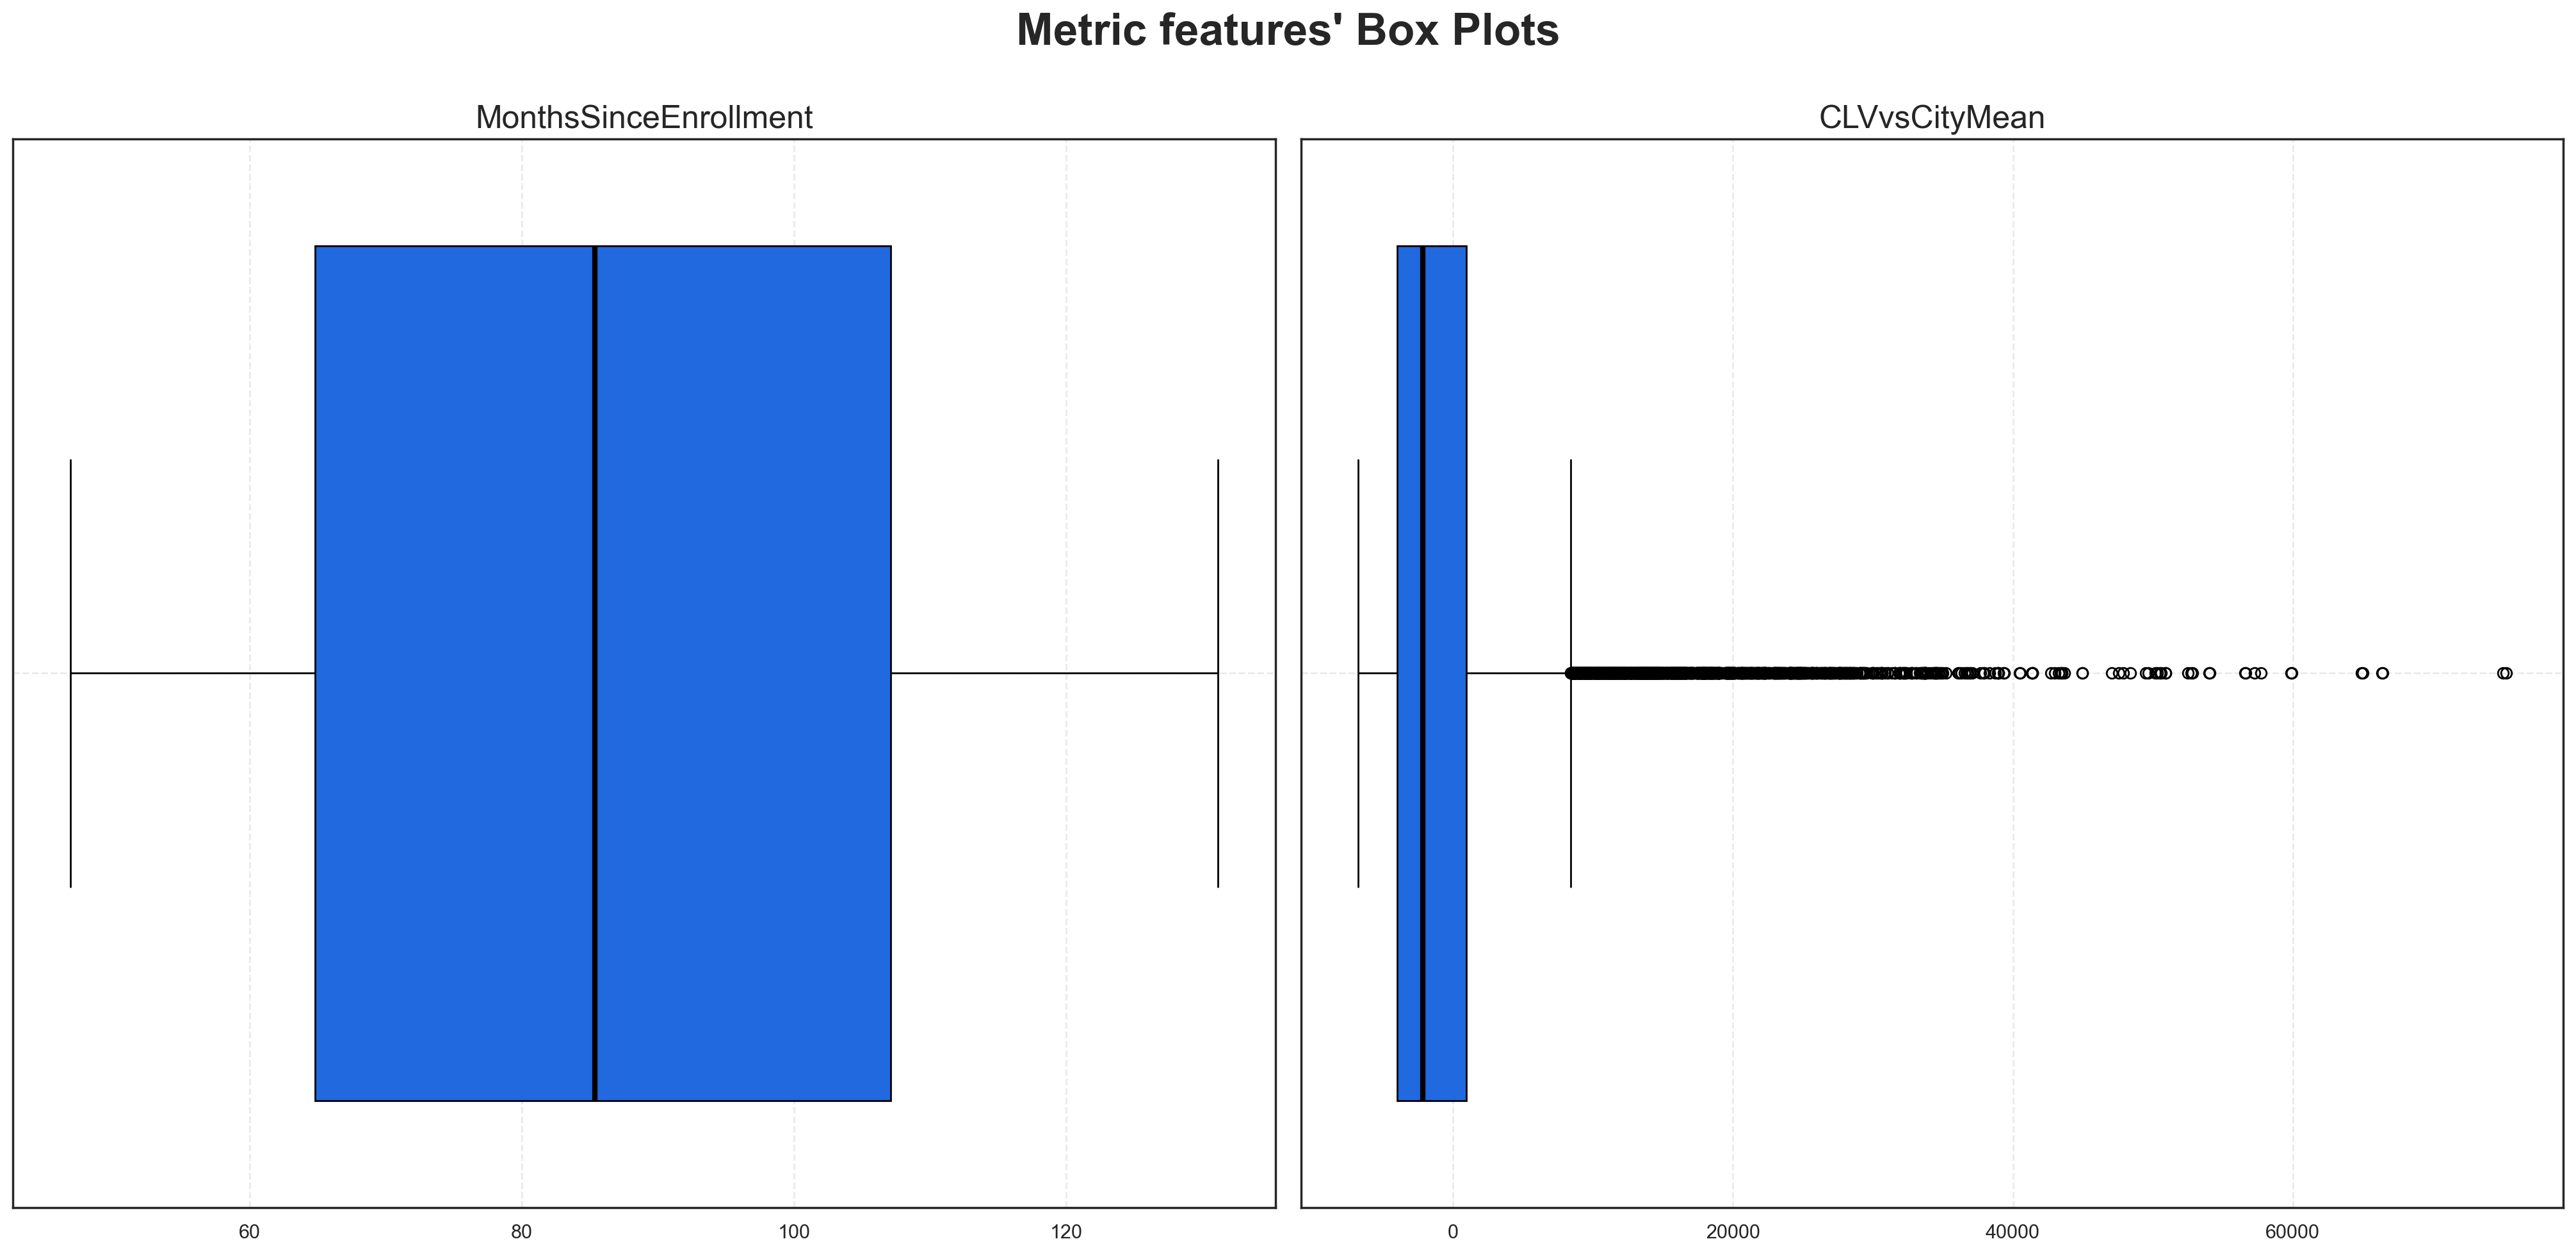

In [27]:
# Prepare figure. Create individual axes where each histogram will be placed
fig, axes = plt.subplots(sp_rows_CDB_new, 
                         sp_cols_CDB_new, 
                         figsize=(20, 10),
                         constrained_layout=True) # Adjust automatically spacing between subplot and labels 

# Increase vertical space between rows
fig.set_constrained_layout_pads(h_pad=.2)

# Plot data
# Iterate across axes objects and associate each box plot:
for ax, feat in zip(axes.flatten(), customerDB_new_cont):
    sns.boxplot(x=customerDB_new_cont[feat].reset_index(drop=True), ax=ax,
                color="#0062FF",
                boxprops=dict(edgecolor="black"),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                medianprops=dict(color="black", linewidth=3),
                flierprops=dict(markeredgecolor="black"))

    
    # Put grid with low opacity and dashed line so it's visible, but not distracting
    ax.grid(True, linestyle="--", alpha=0.4)

    # Put title of each graph with bigger font
    ax.set_title(feat, fontsize=18)

    # Hide x label since we already have the boxlplot title at the top
    ax.set_xlabel("")
    
# Layout
# Add title and make it bigger
plt.suptitle("Metric features' Box Plots", 
             fontsize = 25, fontweight="bold")

# Create the folder '../figures/eda' if it doesn't already exist
os.makedirs(os.path.join('..', 'figures', 'eda'), exist_ok=True)

# Save figure to a png file in the folder created before
plt.savefig(os.path.join('..', 'figures', 'eda', 'numeric_features_boxplots.png'), dpi=200)

# Show plot
plt.show()

Conclusions:
- `MonthsSinceEnrollment:` The distribution is symmetric with minimal outliers, indicating most customers have been enrolled for a similar span, and tenure is not heavily skewed by extreme cases.
- `CLVvsCityMean:` The box plot reveals a strong right skew with numerous high-value outliers, showing that while most customers are near their city’s CLV mean, a few have much higher CLV, standing far apart from the main group.

### Bar Plots

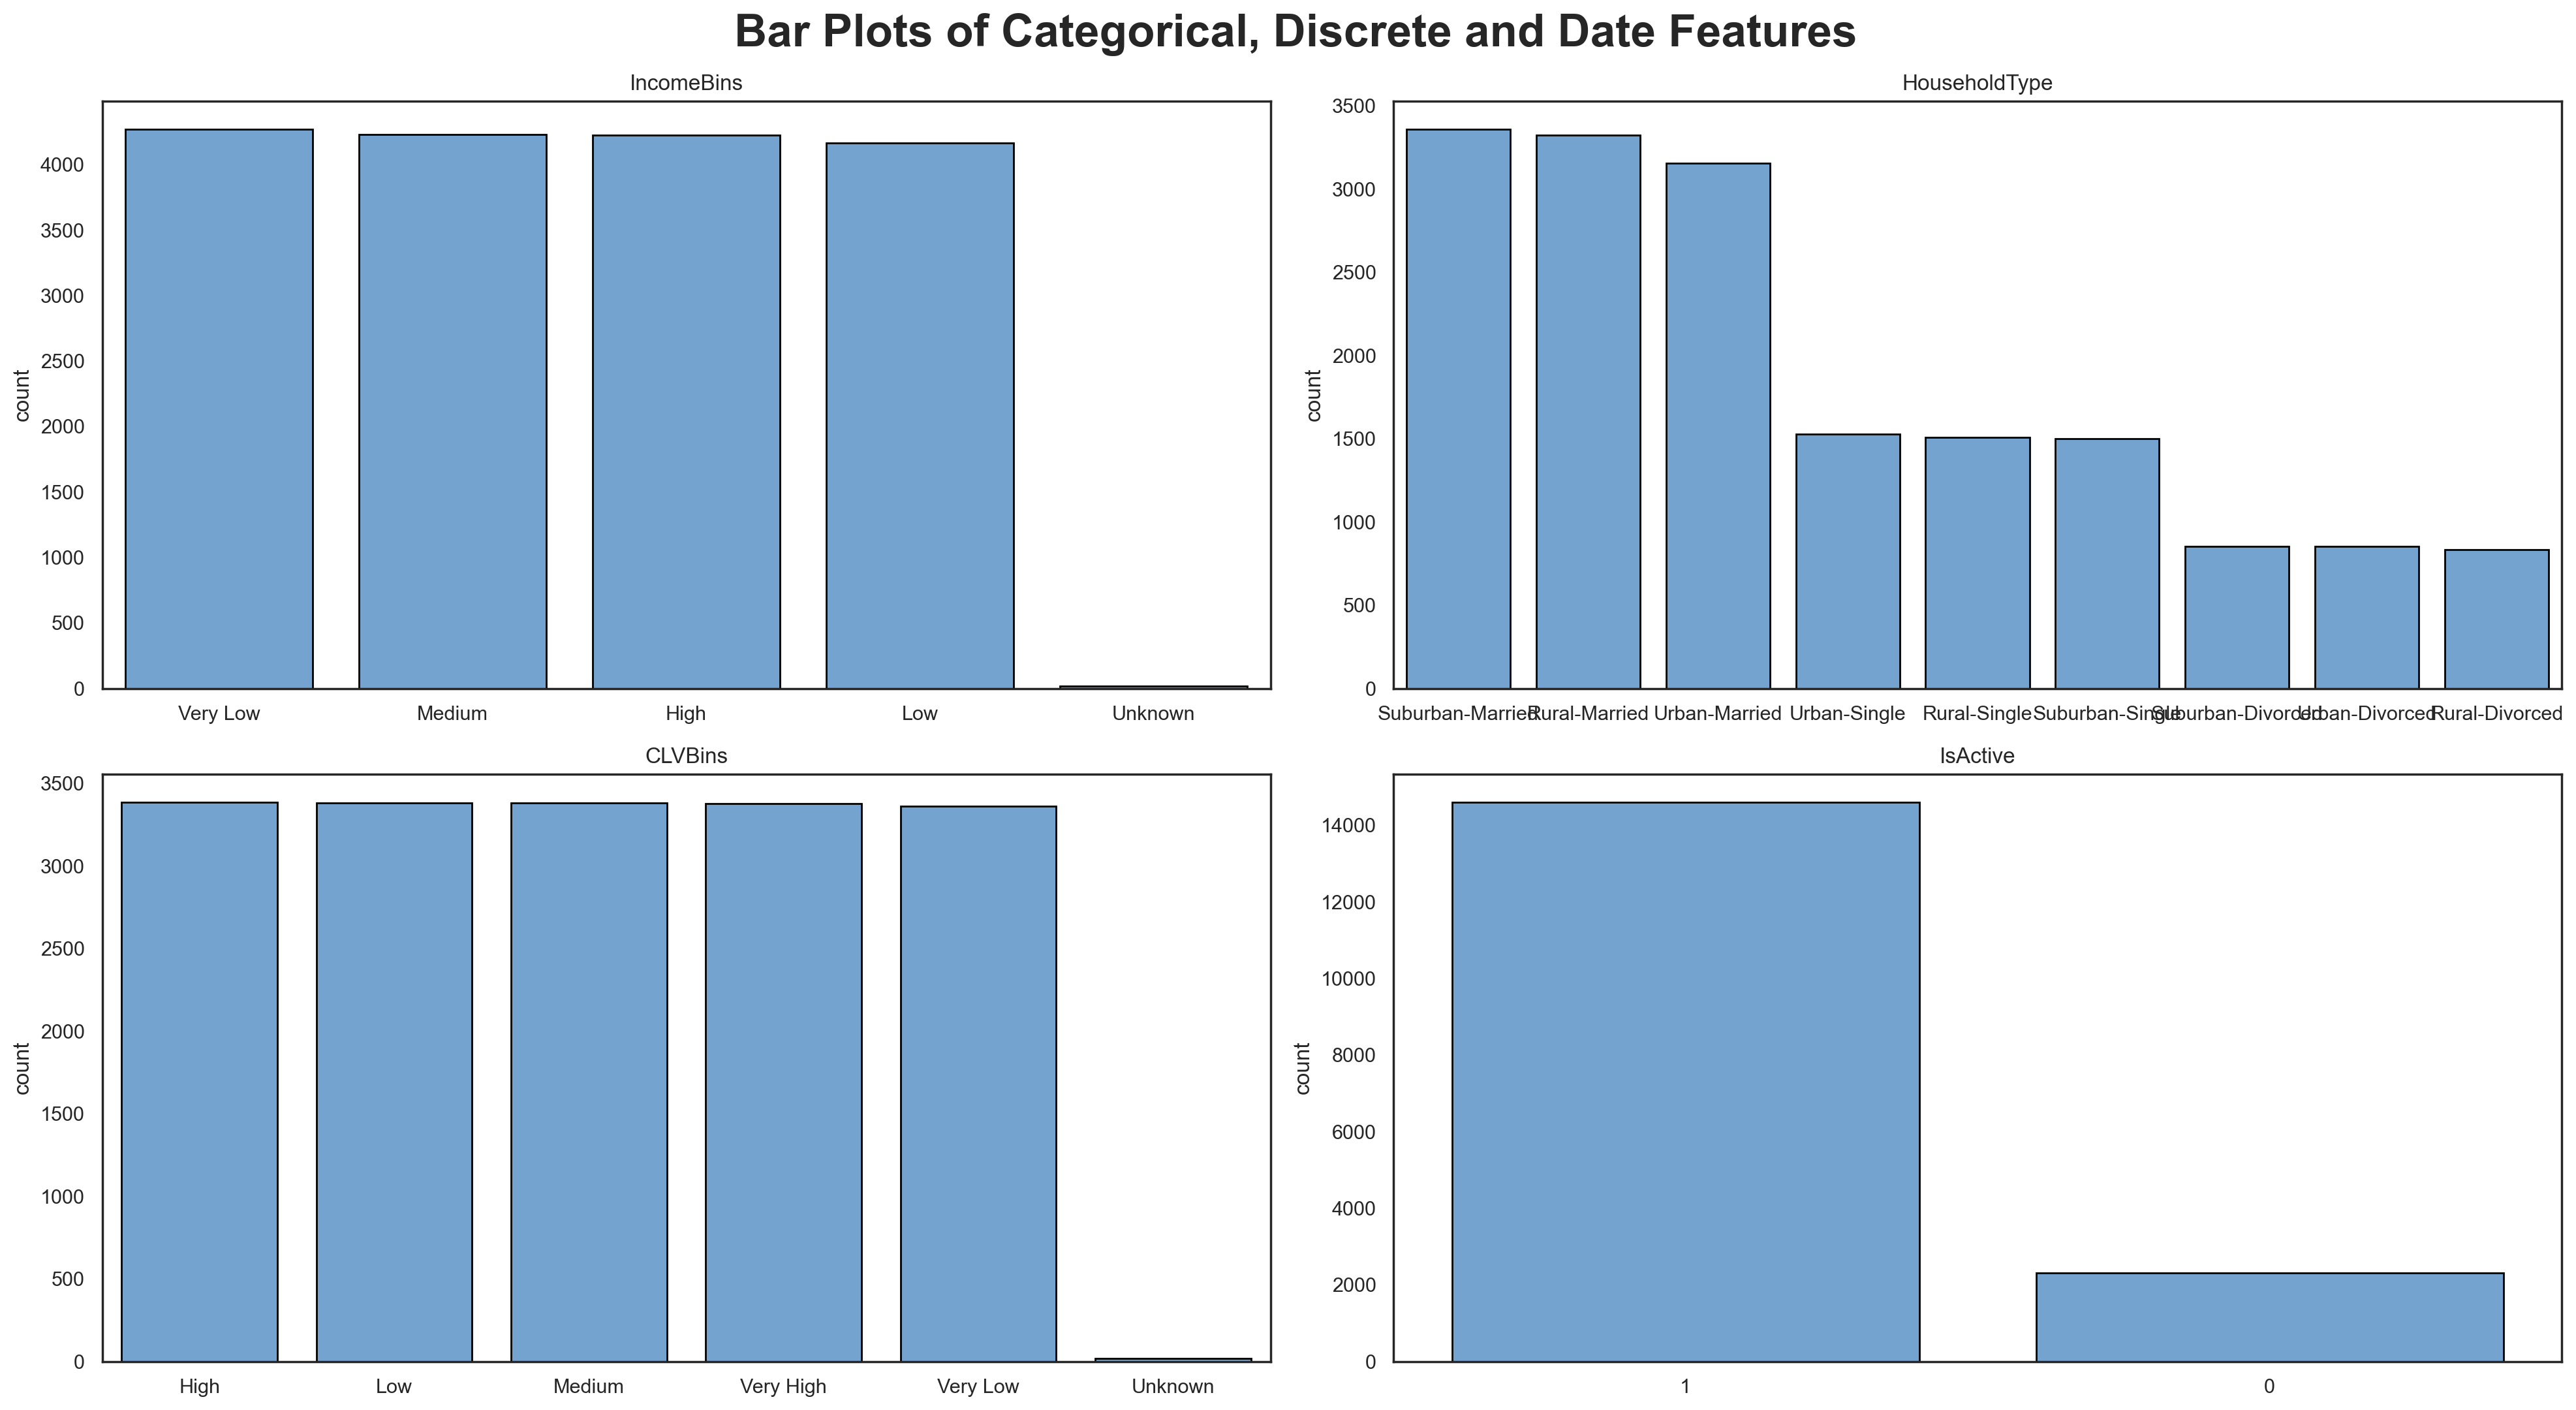

In [28]:
# To do bar plots we use Categorical + Discrete features + dates features

sns.set(style="white")

fig, axes = plt.subplots(2, 2, figsize=(20, 11))

for ax, feat in zip(axes.flatten(), customerDB_new_categ):
    sns.countplot(x=customerDB_new_categ[feat], ax=ax, 
                  order=customerDB_new_categ[feat].value_counts().index, color="#66a4de", edgecolor="black") 
    ax.set_title(feat)
    ax.set_xlabel('') # Remove x-axis label for clarity

plt.suptitle("Bar Plots of Categorical, Discrete and Date Features", fontsize=25, fontweight="bold")
plt.tight_layout() # Adjust spacing to prevent overlap
plt.show()

Conclusions:
- `IncomeBins:` Income is evenly distributed across all bins except 'Unknown,' which is much less frequent, suggesting successful segmentation and few missing values.
- `HouseholdType:` Married households, especially in suburban and rural settings, dominate the dataset, while divorced and single households are less common.
- `CLVBins:` The customer base is evenly segmented across CLV bins except 'Unknown,' indicating balanced customer value groups and minimal missing data.
- `IsActive:` The majority of customers are active, with a far smaller group of inactive users, highlighting a generally engaged customer population.

### Comparing New Categorical Features

We will compare these new categorical features: IncomeBins, HouseholdType and CLVBins.

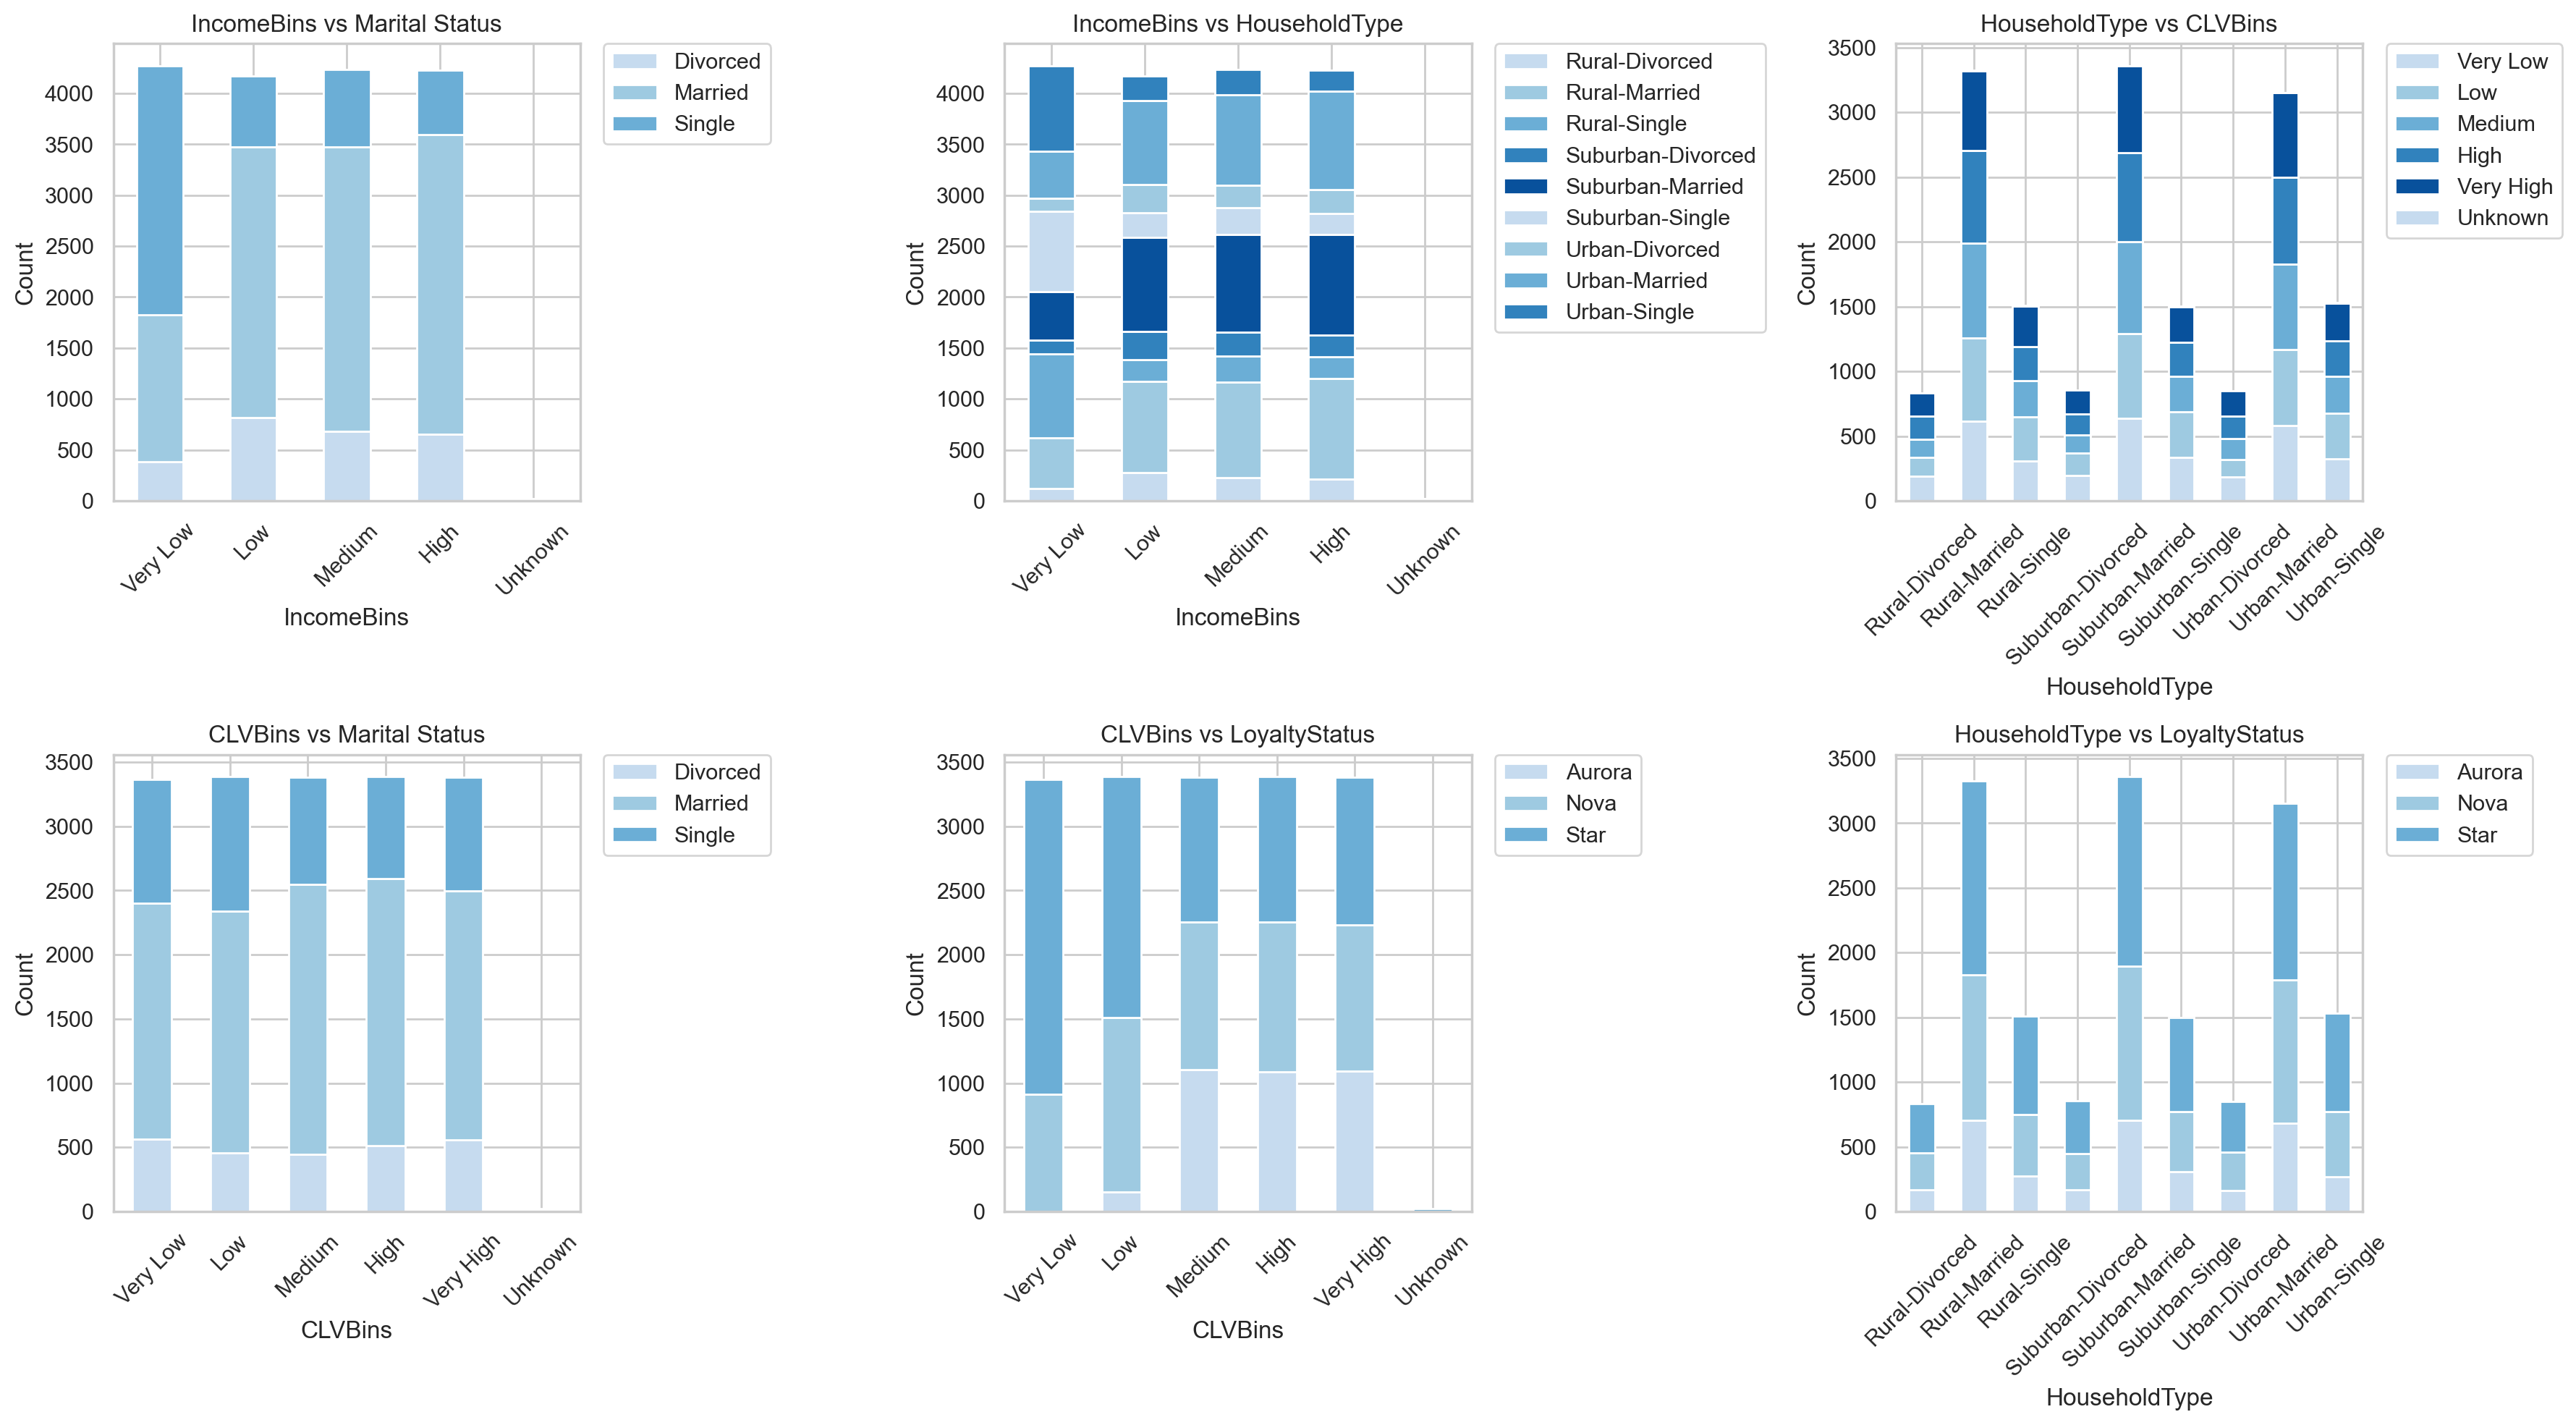

In [30]:
# Style setting
sns.set(style="whitegrid")

# Generate all 2-way combinations
pairs_to_plot = [
    ('IncomeBins', 'Marital Status'),
    ('IncomeBins', 'HouseholdType'),
    ('HouseholdType', 'CLVBins'),
    ('CLVBins', 'Marital Status'),
    ('CLVBins', 'LoyaltyStatus'),
    ('HouseholdType', 'LoyaltyStatus'),
]

# Create figure with subplots
fig, axes = plt.subplots(2, 3 , figsize=(18, 10))
axes = axes.flatten()

# Generate a plot for each pair
for i, (x, y) in enumerate(pairs_to_plot):
    pd.crosstab(dfs_merged[x], dfs_merged[y]).plot(kind='bar', stacked=True, ax=axes[i], color=['#c6dbef', '#9ecae1', '#6baed6', '#3182bd', '#08519c'])
    axes[i].set_title(f"{x} vs {y}")
    axes[i].set_xlabel(x)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    

# Delete unused subplots
for j in range(10, len(axes)):
    fig.delaxes(axes[j]) 
    
plt.tight_layout()
plt.show()

Conclusions:
- `IncomeBins vs Marital Status:` Across most income bins, married customers consistently represent the largest segment, except for the 'Very Low' bin, which probably represents the younger customers. Singles and divorced are each a smaller but steady proportion except for the first bin, indicating marital status is relatively independent of income tier.

- `IncomeBins vs HouseholdType:` Regardless of income group, suburban-married and rural-married households are dominant, while single and divorced types, especially in urban and suburban settings, are much less frequent.

- `HouseholdType vs CLVBins:` In terms of frequency, high and very high CLV categories are most associated with married households (especially rural and suburban), confirming their value. However, in relative terms, the CLV bins are equally distributed in all household types.

- `CLVBins vs Marital Status:` Higher CLV bins have a slightly greater share of married customers, while single and divorced customers are distributed more evenly across value tiers.

- `CLVBins vs LoyaltyStatus:` Aurora and Nova loyalty statuses become more prevalent in higher CLV bins, suggesting that highly valuable customers are also likely to hold premium loyalty tiers.

- `HouseholdType vs LoyaltyStatus:` The Loyalty Status distributions are constant through all the Household Types, the differences being very minimal.

## Merged Datasets

We only created numeric features for merged datasets.

### Histograms

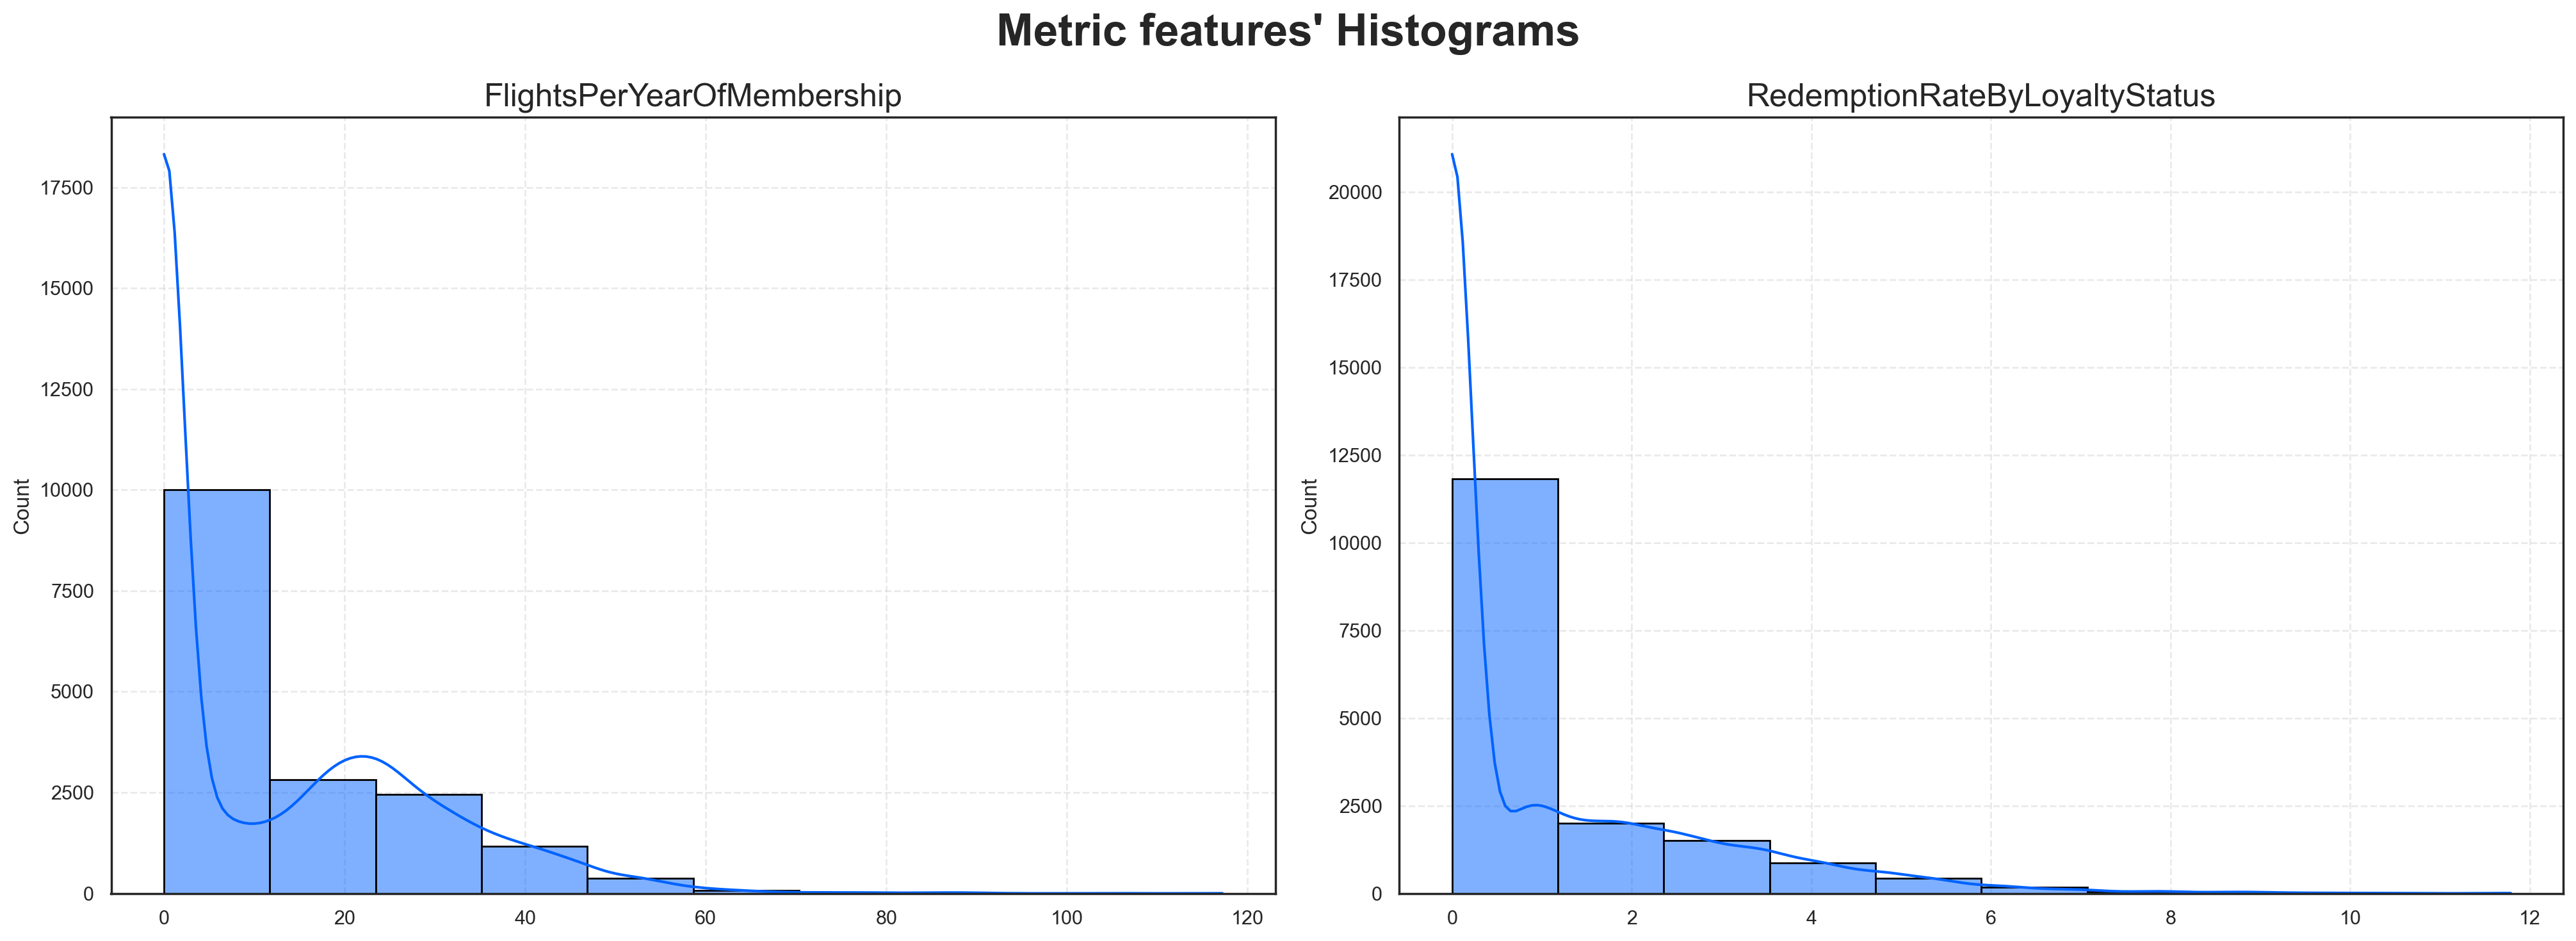

In [32]:
# Set number of rows and columns
sp_rows_merged = 1
sp_cols_merged = 2

# Set style
sns.set_style("white") # increase contrast

# Create figure
fig, axes = plt.subplots(sp_rows_merged,
                         sp_cols_merged,
                         figsize=(20, 7),
                         constrained_layout=True)

# Additional spacing between rows
fig.set_constrained_layout_pads(h_pad=.2)

# Plot data
for ax, feat in zip(axes.flatten(), dfs_merged_new):
    
    sns.histplot(dfs_merged_new[feat],
                 bins=10,
                 kde=(feat in dfs_merged_new.columns), #smooth line only for continuous features
                 ax=ax,
                 color="#0062FF",
                 edgecolor="black")
    
    ax.set_title(feat, fontsize=18)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_xlabel("")

# Global title
plt.suptitle("Metric features' Histograms",
             fontsize=25,
             fontweight="bold",
             y=1.05)

# Save figure
os.makedirs(os.path.join('..', 'figures', 'eda'), exist_ok=True)
fig.savefig(os.path.join('..', 'figures', 'eda', 'dfs_merged_new.png'),
            dpi=200)

# display output
plt.show()

Conclusions:
- `FlightsPerYearOfMembership:` Most customers take relatively few flights per year, but the distribution reveals a long right tail, highlighting a smaller segment who fly frequently and may represent high-value or business traveler groups.

- `RedemptionRateByLoyaltyStatus:` The majority of customers are in par with their loyalty status, shown by the sharp drop-off in observations as rates increase, indicating that only a few loyalty members regularly take advantage of redemption opportunities at high levels.

### Boxplots

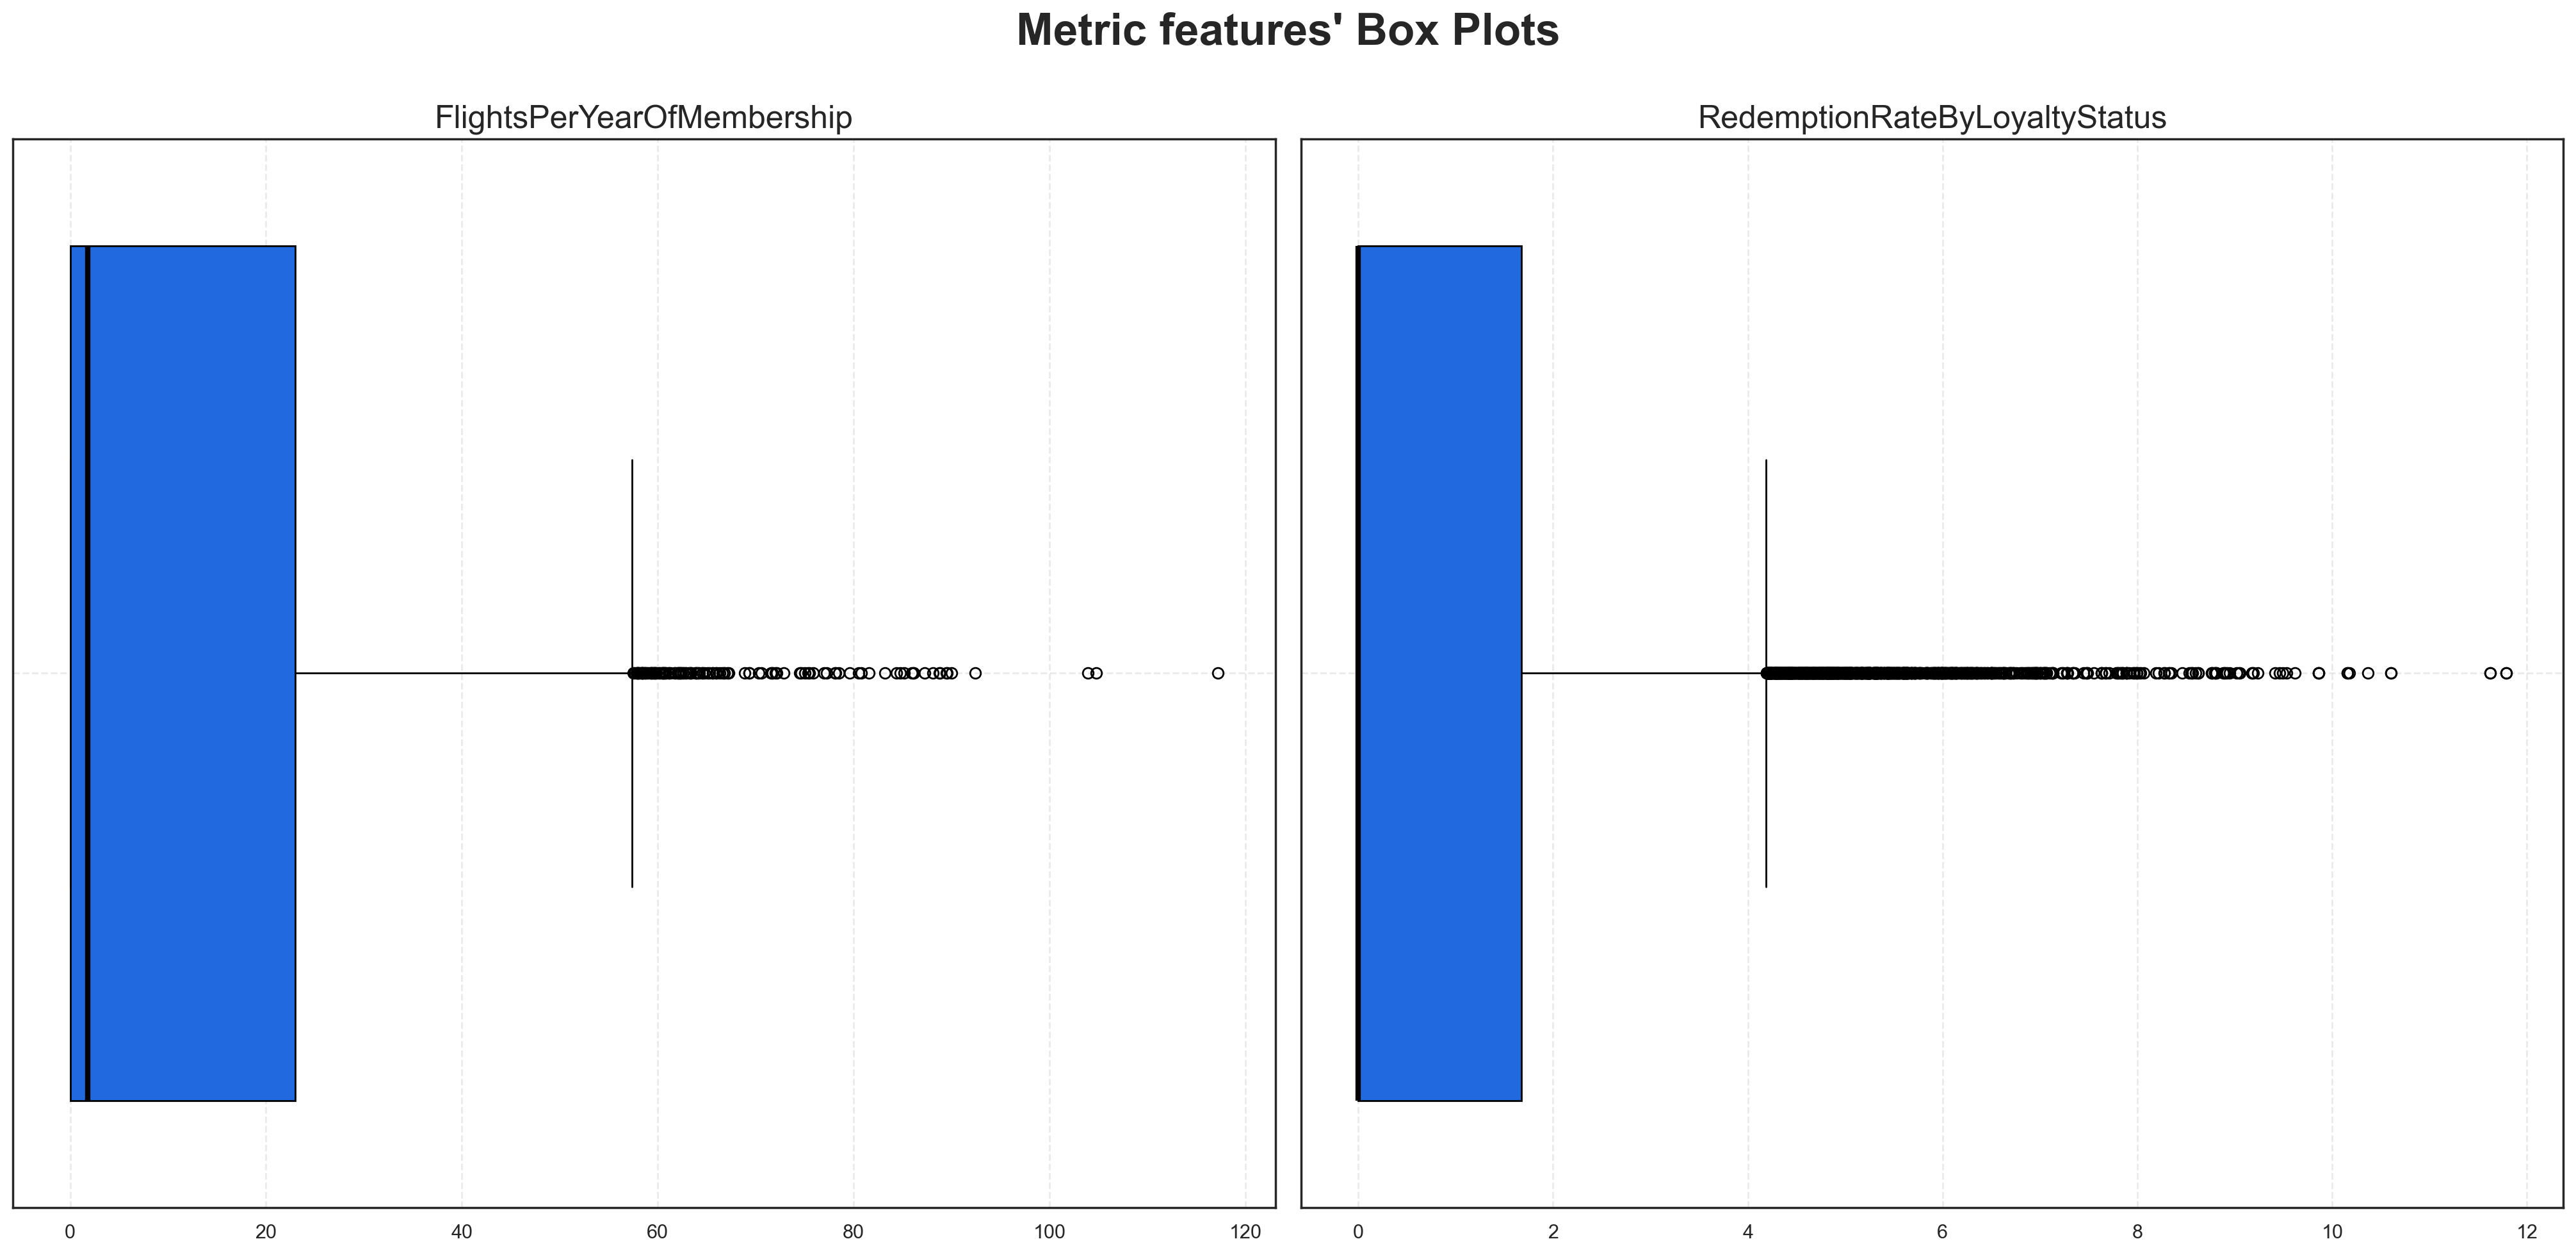

In [33]:
# Prepare figure. Create individual axes where each histogram will be placed
fig, axes = plt.subplots(sp_rows_merged, 
                         sp_cols_merged, 
                         figsize=(20, 10),
                         constrained_layout=True) # Adjust automatically spacing between subplot and labels 

# Increase vertical space between rows
fig.set_constrained_layout_pads(h_pad=.2)

# Plot data
# Iterate across axes objects and associate each box plot:
for ax, feat in zip(axes.flatten(), dfs_merged_new):
    sns.boxplot(x=dfs_merged_new[feat].reset_index(drop=True), ax=ax,
                color="#0062FF",
                boxprops=dict(edgecolor="black"),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                medianprops=dict(color="black", linewidth=3),
                flierprops=dict(markeredgecolor="black"))

    
    # Put grid with low opacity and dashed line so it's visible, but not distracting
    ax.grid(True, linestyle="--", alpha=0.4)

    # Put title of each graph with bigger font
    ax.set_title(feat, fontsize=18)

    # Hide x label since we already have the boxlplot title at the top
    ax.set_xlabel("")
    
# Layout
# Add title and make it bigger
plt.suptitle("Metric features' Box Plots", 
             fontsize = 25, fontweight="bold")

# Create the folder '../figures/eda' if it doesn't already exist
os.makedirs(os.path.join('..', 'figures', 'eda'), exist_ok=True)

# Save figure to a png file in the folder created before
plt.savefig(os.path.join('..', 'figures', 'eda', 'numeric_features_boxplots.png'), dpi=200)

# Show plot
plt.show()

Conclusions:
- `FlightsPerYearOfMembership:` Most customers average a modest number of flights per year, but from the third quartile up to the upper whisker, there emerges a distinct group of highly frequent flyers who stand out as the most engaged segment in the dataset. Moreover, there is a significant number of outliers that fly very frequently.

- `RedemptionRateByLoyaltyStatus:` The majority of loyalty members redeem at a low to moderate rate; nevertheless, there is a long tail of high redemption outliers, indicating varied usage of loyalty benefits.